#  Prediksi Harga Rumah
## Perbandingan Multiple Linear Regression, Random Forest, dan XGBoost


## 1. Import Libraries


In [29]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
from scipy.stats import skew, kurtosis
import time


## 2. Load dan Eksplorasi Data


In [30]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')

# Path ke file di Google Drive
file_path = '/content/drive/MyDrive/HousePrediction/train.csv'

df = pd.read_csv(file_path)

print("="*80)
print("INFORMASI DATASET")
print("="*80)
print(f"\nDimensi Dataset: {df.shape[0]} baris × {df.shape[1]} kolom")

# Tampilkan 5 baris pertama
print("\n 5 Baris Pertama Dataset:")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INFORMASI DATASET

Dimensi Dataset: 1460 baris × 81 kolom

 5 Baris Pertama Dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [31]:
# Info dataset
print("\n Informasi Tipe Data:")
df.info()


 Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null 

In [32]:
# Statistik deskriptif untuk kolom numerik
print("Statistik Deskriptif (Kolom Numerik):")
df.describe().T

Statistik Deskriptif (Kolom Numerik):


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



Analisa Missing Values:
Total kolom dengan missing values: 19

Detail Missing Values:
           Kolom  Missing_Count  Missing_Percentage
0         PoolQC           1453           99.520548
1    MiscFeature           1406           96.301370
2          Alley           1369           93.767123
3          Fence           1179           80.753425
4     MasVnrType            872           59.726027
5    FireplaceQu            690           47.260274
6    LotFrontage            259           17.739726
7     GarageType             81            5.547945
8    GarageYrBlt             81            5.547945
9   GarageFinish             81            5.547945
10    GarageQual             81            5.547945
11    GarageCond             81            5.547945
12  BsmtExposure             38            2.602740
13  BsmtFinType2             38            2.602740
14      BsmtQual             37            2.534247
15      BsmtCond             37            2.534247
16  BsmtFinType1             

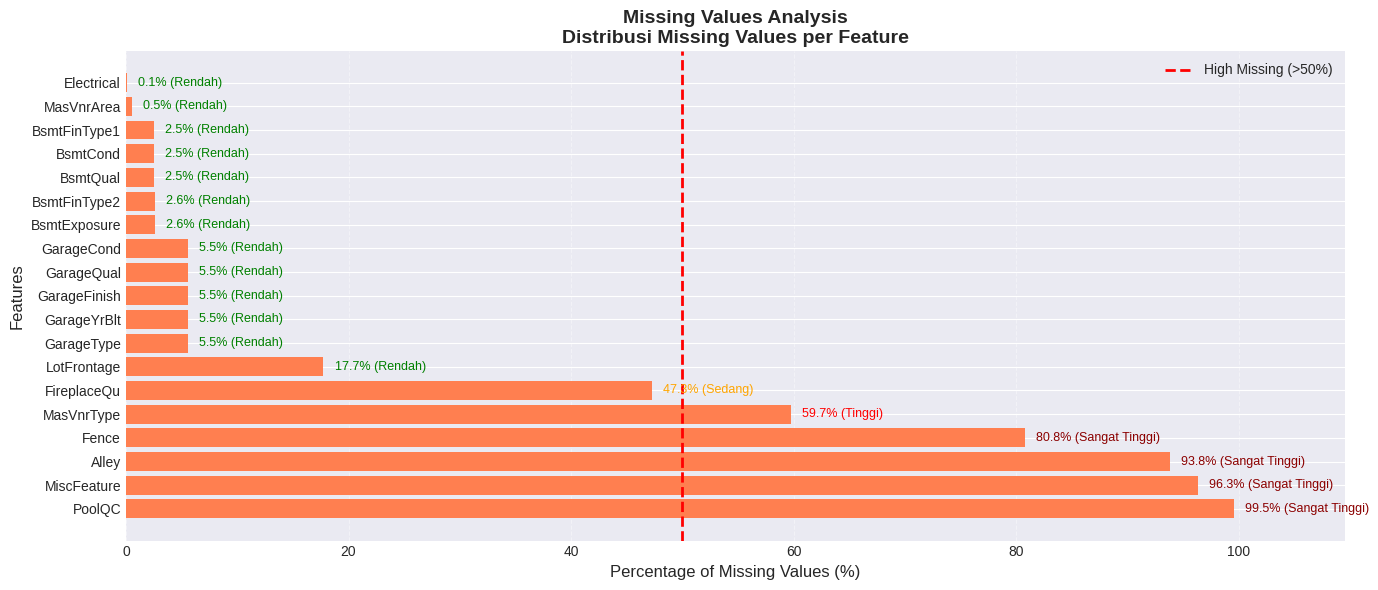

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
#  MISSING VALUES
# =========================
missing_data = pd.DataFrame({
    'Kolom': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0] \
    .sort_values('Missing_Percentage', ascending=False) \
    .reset_index(drop=True)

print("\nAnalisa Missing Values:")
print("="*80)
print(f"Total kolom dengan missing values: {len(missing_data)}")
print(f"\nDetail Missing Values:")
print(missing_data.to_string())


# =========================
# VISUALISASI
# =========================
if len(missing_data) > 0:
    plt.figure(figsize=(14, 6))

    # Bar chart
    bars = plt.barh(
        missing_data['Kolom'],
        missing_data['Missing_Percentage'],
        color='coral'
    )

    # Garis threshold
    plt.axvline(
        x=50,
        color='red',
        linestyle='--',
        linewidth=2,
        label='High Missing (>50%)'
    )

    for i, v in enumerate(missing_data['Missing_Percentage']):
        # Tentukan kategori + warna
        if v > 80:
            label = "Sangat Tinggi"
            color = "darkred"
        elif v > 50:
            label = "Tinggi"
            color = "red"
        elif v > 20:
            label = "Sedang"
            color = "orange"
        else:
            label = "Rendah"
            color = "green"

        # Tampilkan di ujung bar
        plt.text(
            v + 1,
            i,
            f"{v:.1f}% ({label})",
            va='center',
            fontsize=9,
            color=color
        )

    plt.xlim(0, missing_data['Missing_Percentage'].max() + 10)

    plt.xlabel('Percentage of Missing Values (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title('Missing Values Analysis\nDistribusi Missing Values per Feature',fontsize=14, fontweight='bold')

    plt.legend()
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

else:
    print("Tidak ada missing values dalam dataset!")

## 3. Exploratory Data Analysis (EDA)

### 3.1 Analisis Target Variable (SalePrice)

ANALISIS TARGET VARIABLE: SALE PRICE

Mean       : $180,921.20
Median     : $163,000.00
Std Dev    : $79,442.50
Min        : $34,900.00
Max        : $755,000.00
Range      : $720,100.00

Skewness   : 1.8829
Kurtosis   : 6.5363


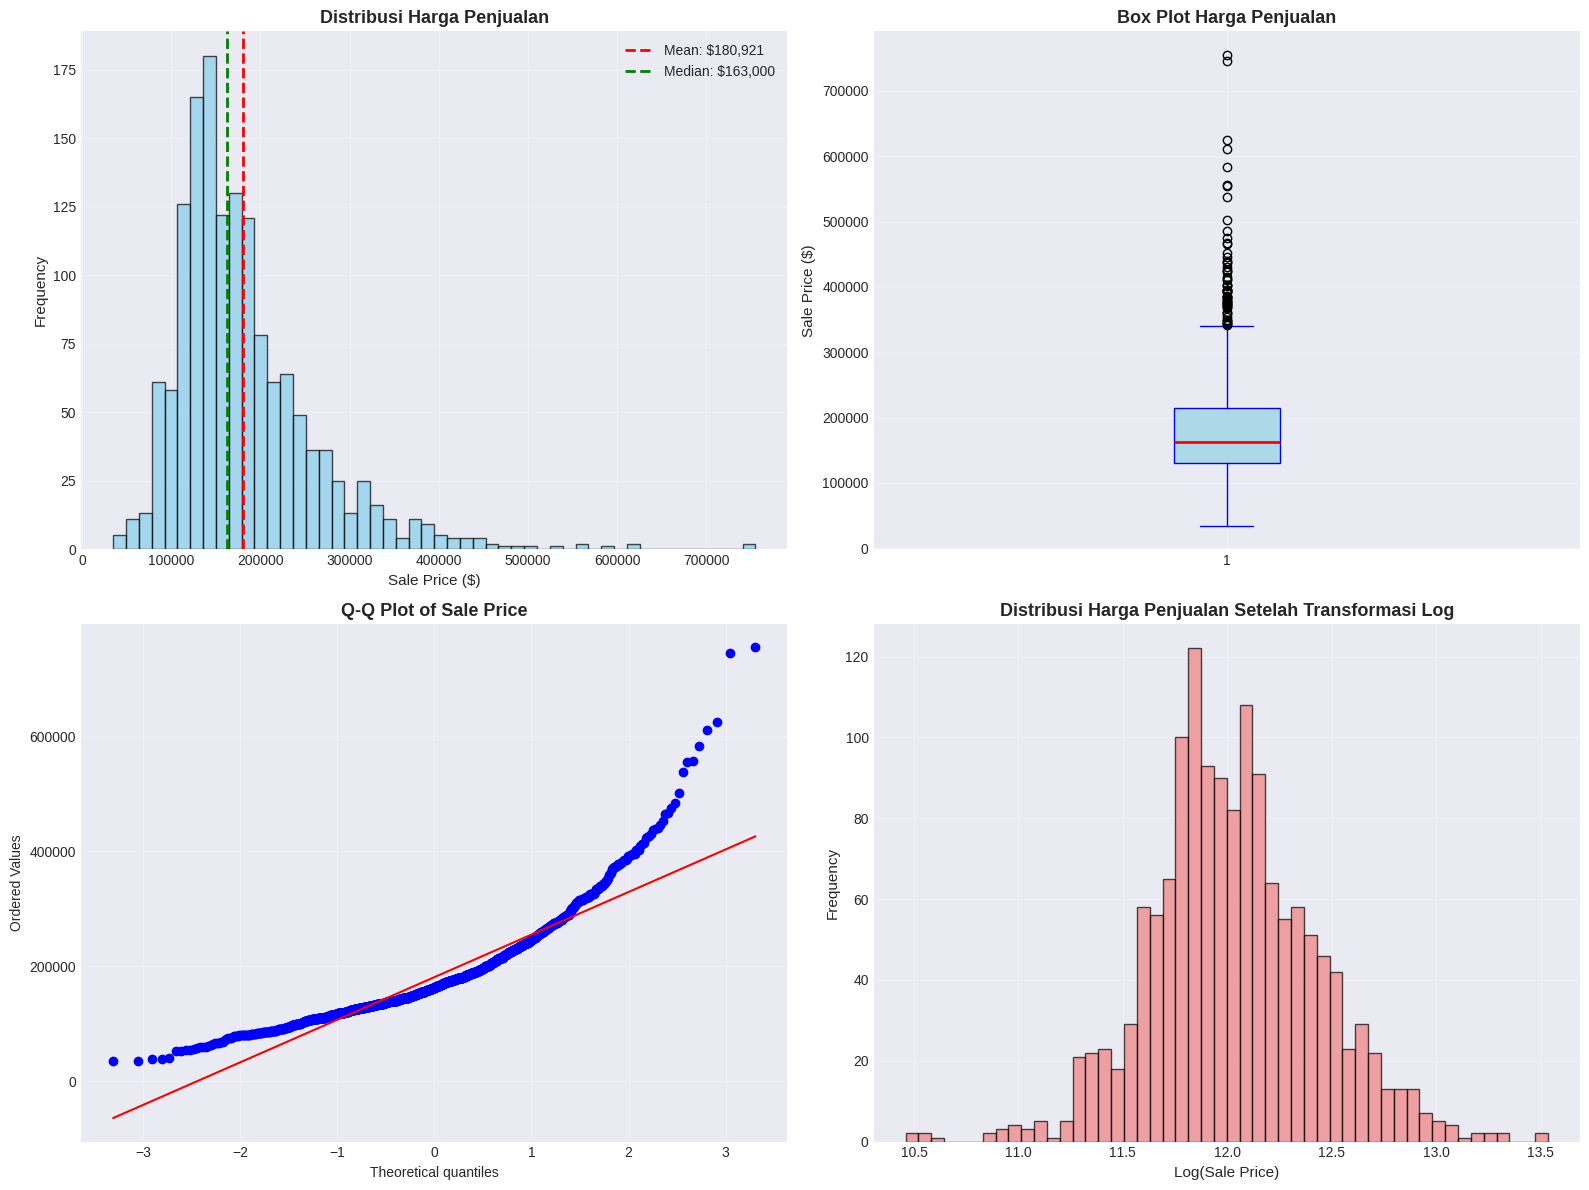


Setelah Log Transform:
Skewness   : 0.1213
Kurtosis   : 0.8095


In [34]:
# Statistik SalePrice
print("="*80)
print("ANALISIS TARGET VARIABLE: SALE PRICE")
print("="*80)
print(f"\nMean       : ${df['SalePrice'].mean():,.2f}")
print(f"Median     : ${df['SalePrice'].median():,.2f}")
print(f"Std Dev    : ${df['SalePrice'].std():,.2f}")
print(f"Min        : ${df['SalePrice'].min():,.2f}")
print(f"Max        : ${df['SalePrice'].max():,.2f}")
print(f"Range      : ${df['SalePrice'].max() - df['SalePrice'].min():,.2f}")
print(f"\nSkewness   : {df['SalePrice'].skew():.4f}")
print(f"Kurtosis   : {df['SalePrice'].kurtosis():.4f}")

# Visualisasi distribusi SalePrice
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(df['SalePrice'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["SalePrice"].mean():,.0f}')
axes[0, 0].axvline(df['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["SalePrice"].median():,.0f}')
axes[0, 0].set_xlabel('Sale Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribusi Harga Penjualan', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Box Plot
axes[0, 1].boxplot(df['SalePrice'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='blue'),
                   capprops=dict(color='blue'))
axes[0, 1].set_ylabel('Sale Price ($)', fontsize=11)
axes[0, 1].set_title('Box Plot Harga Penjualan', fontsize=13, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Q-Q Plot
stats.probplot(df['SalePrice'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Sale Price', fontsize=13, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Log Transform
log_prices = np.log1p(df['SalePrice'])
axes[1, 1].hist(log_prices, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Log(Sale Price)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribusi Harga Penjualan Setelah Transformasi Log', fontsize=13, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSetelah Log Transform:")
print(f"Skewness   : {log_prices.skew():.4f}")
print(f"Kurtosis   : {log_prices.kurtosis():.4f}")

### 3.2 Analisis Korelasi Features

In [35]:
# Pisahkan kolom numerik dan kategorikal
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Hapus 'Id' dari numeric features jika ada
if 'Id' in numeric_features:
    numeric_features.remove('Id')

print("="*80)
print("TIPE FEATURES")
print("="*80)
print(f"\nNumeric Features: {len(numeric_features)} kolom")
print(f"Categorical Features: {len(categorical_features)} kolom")
print(f"\nContoh Numeric Features: {numeric_features[:10]}")
print(f"\nContoh Categorical Features: {categorical_features[:10]}")

TIPE FEATURES

Numeric Features: 37 kolom
Categorical Features: 43 kolom

Contoh Numeric Features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']

Contoh Categorical Features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']



 TOP 15 FEATURES BERKORELASI DENGAN SALEPRICE:
 1. OverallQual          : +0.7910
 2. GrLivArea            : +0.7086
 3. GarageCars           : +0.6404
 4. GarageArea           : +0.6234
 5. TotalBsmtSF          : +0.6136
 6. 1stFlrSF             : +0.6059
 7. FullBath             : +0.5607
 8. TotRmsAbvGrd         : +0.5337
 9. YearBuilt            : +0.5229
10. YearRemodAdd         : +0.5071
11. GarageYrBlt          : +0.4864
12. MasVnrArea           : +0.4775
13. Fireplaces           : +0.4669
14. BsmtFinSF1           : +0.3864
15. LotFrontage          : +0.3518


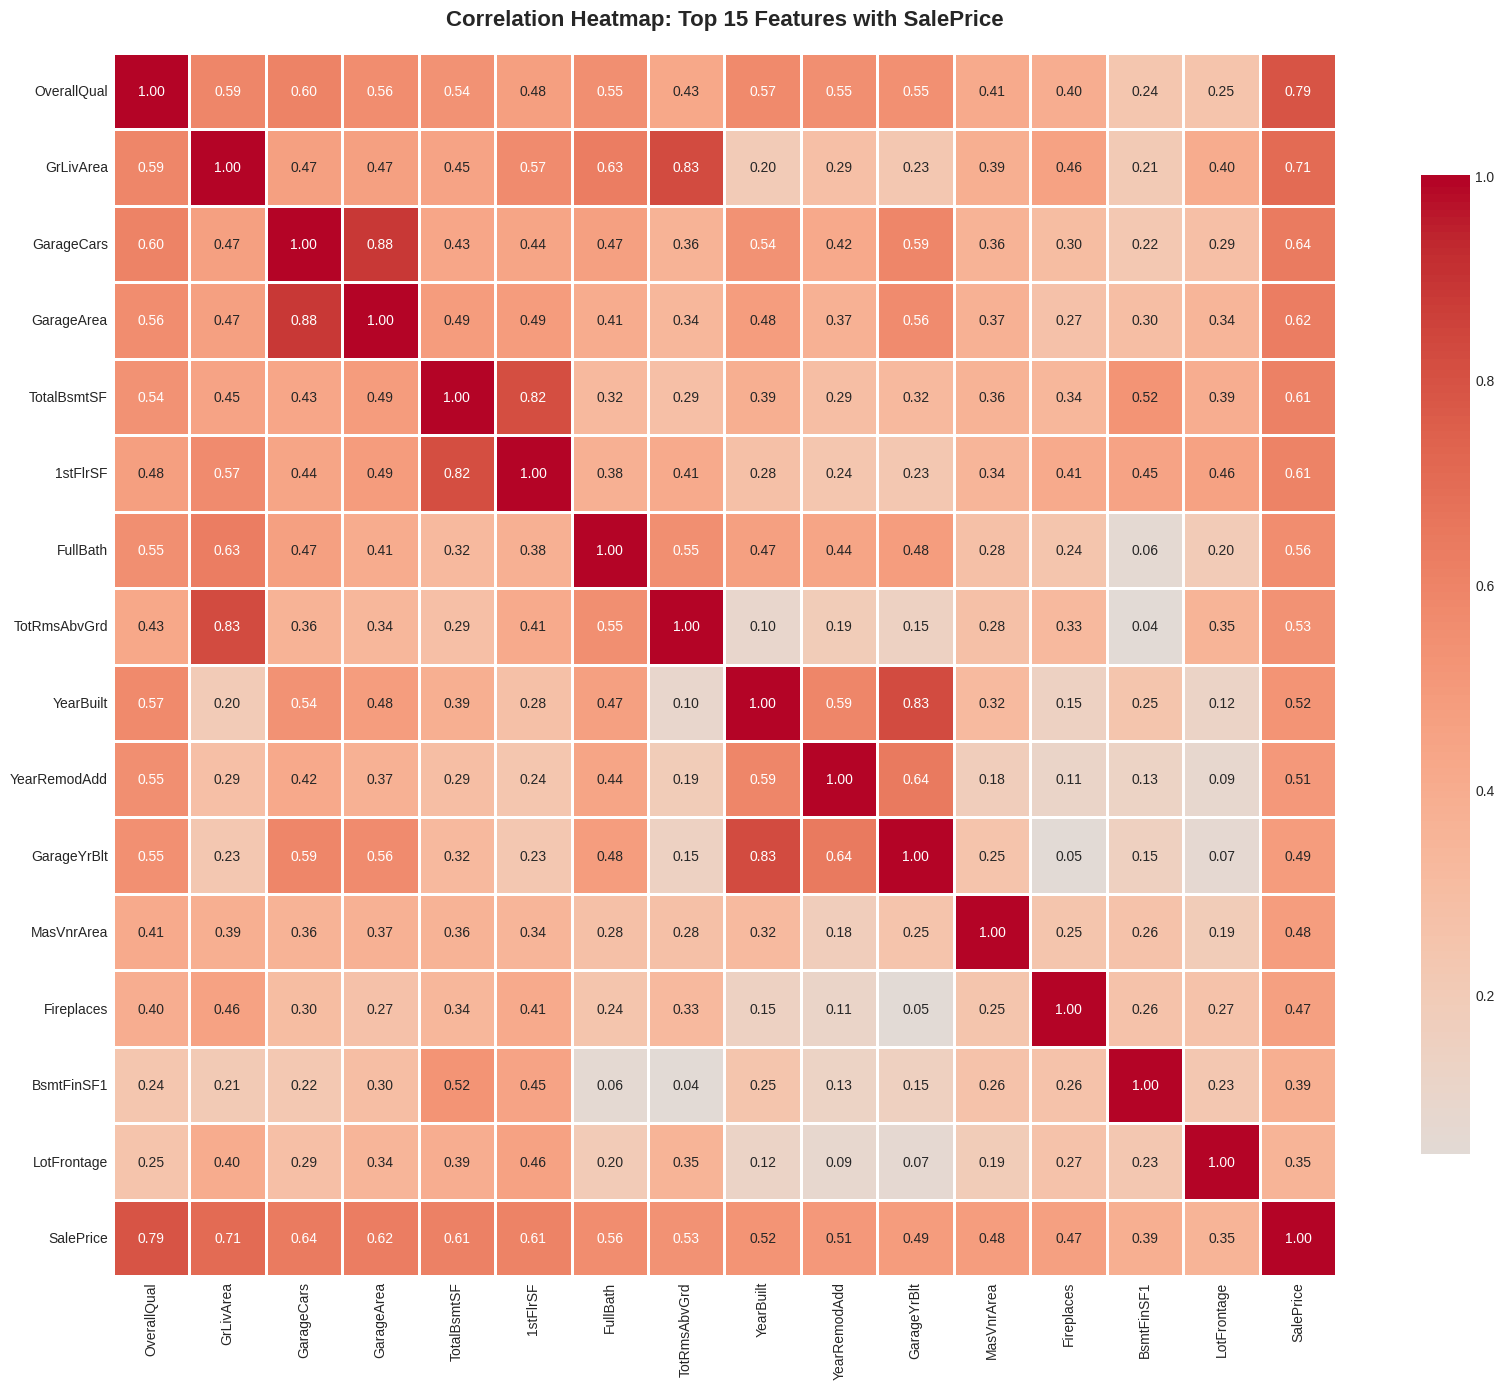

In [36]:
# Correlation matrix untuk numeric features
corr_matrix = df[numeric_features].corr()

# Top 15 features yang berkorelasi dengan SalePrice
corr_with_target = corr_matrix['SalePrice'].sort_values(ascending=False)
top_15_corr = corr_with_target[1:16]  # Exclude SalePrice itself

print("\n TOP 15 FEATURES BERKORELASI DENGAN SALEPRICE:")
print("="*80)
for idx, (feature, corr_value) in enumerate(top_15_corr.items(), 1):
    print(f"{idx:2d}. {feature:20s} : {corr_value:+.4f}")

# Visualisasi correlation heatmap
plt.figure(figsize=(18, 14))
top_features = top_15_corr.index.tolist() + ['SalePrice']
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Top 15 Features with SalePrice',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 3.3 Visualisasi Hubungan Top Features dengan SalePrice

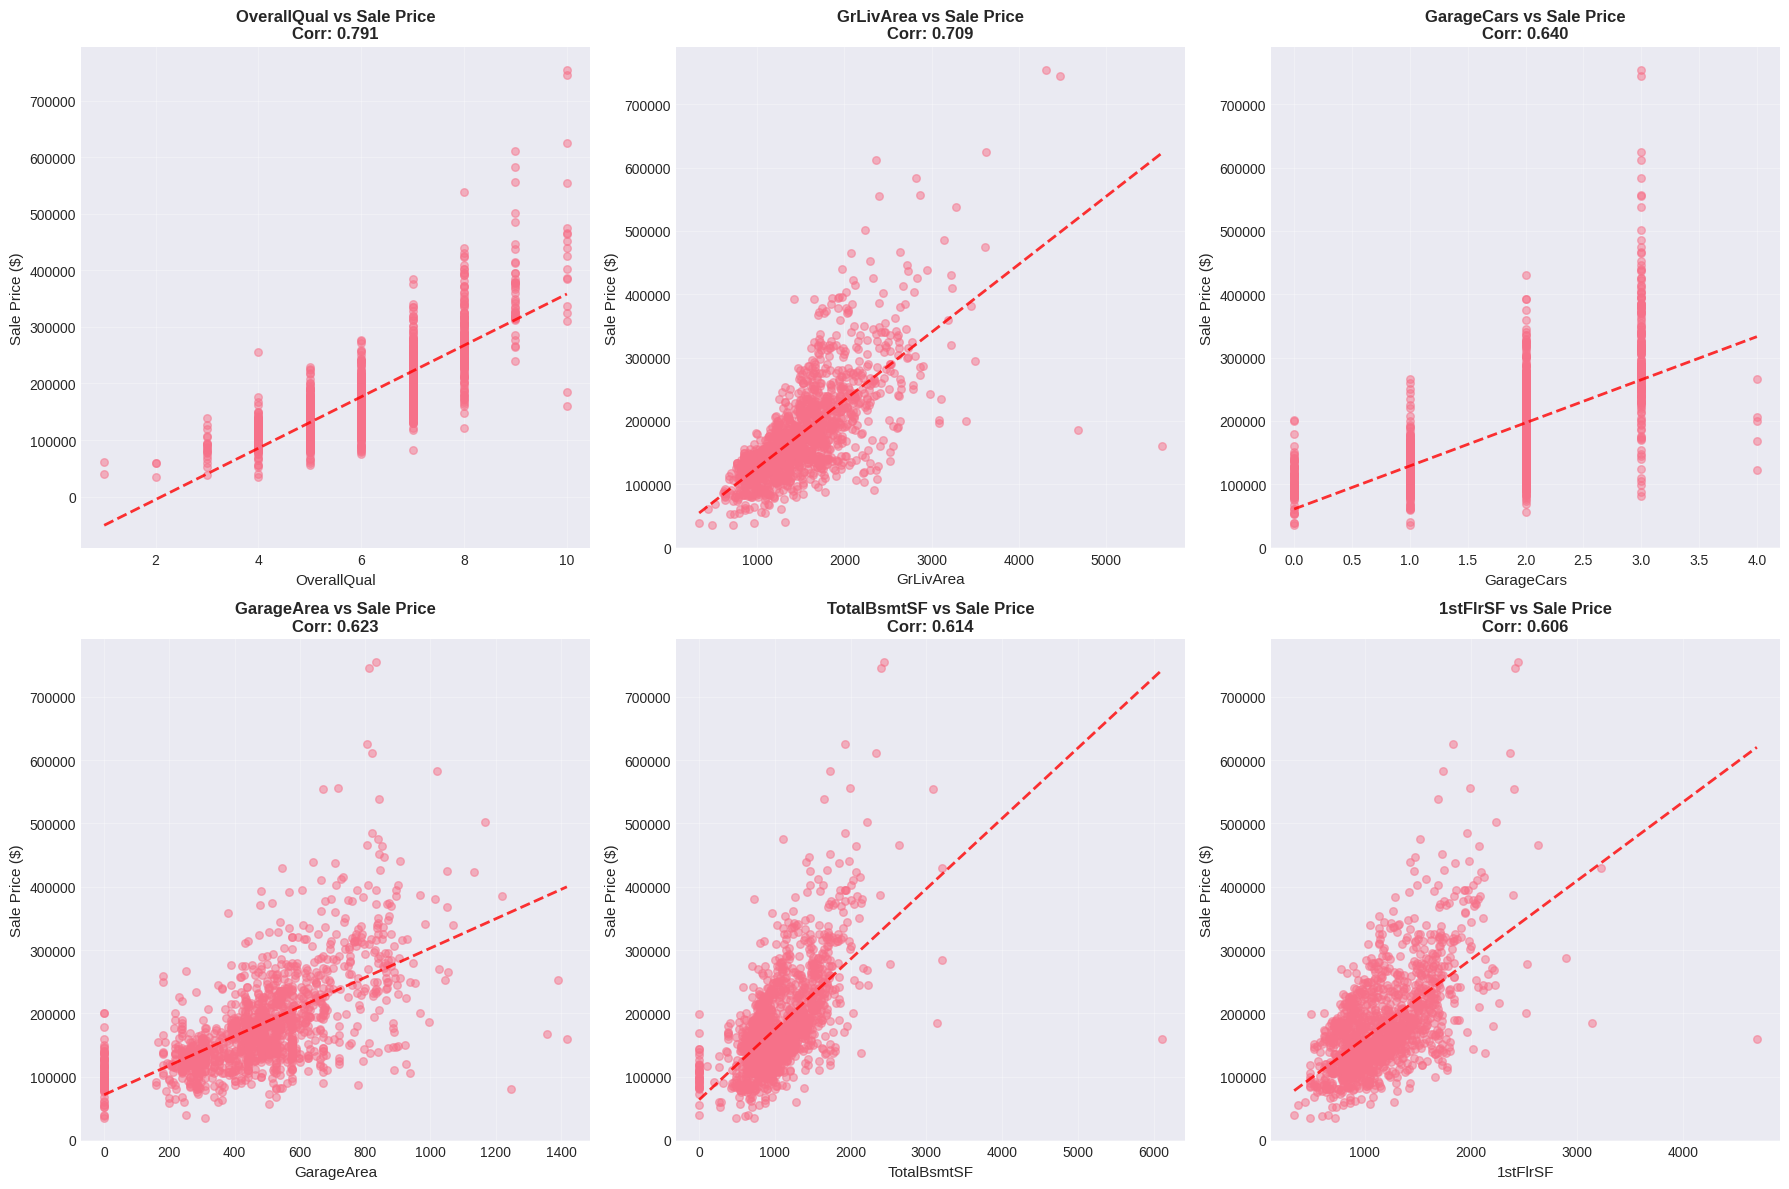

In [37]:
# Scatter plots untuk top 6 numeric features
top_6_features = top_15_corr.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_6_features):
    axes[idx].scatter(df[feature], df['SalePrice'], alpha=0.5, s=30)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Sale Price ($)', fontsize=11)
    axes[idx].set_title(f'{feature} vs Sale Price\nCorr: {corr_with_target[feature]:.3f}',
                        fontsize=12, fontweight='bold')

    # Add trend line
    z = np.polyfit(df[feature].dropna(), df.loc[df[feature].notna(), 'SalePrice'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature].sort_values(), p(df[feature].sort_values()),
                   "r--", linewidth=2, alpha=0.8)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Analisis Categorical Features

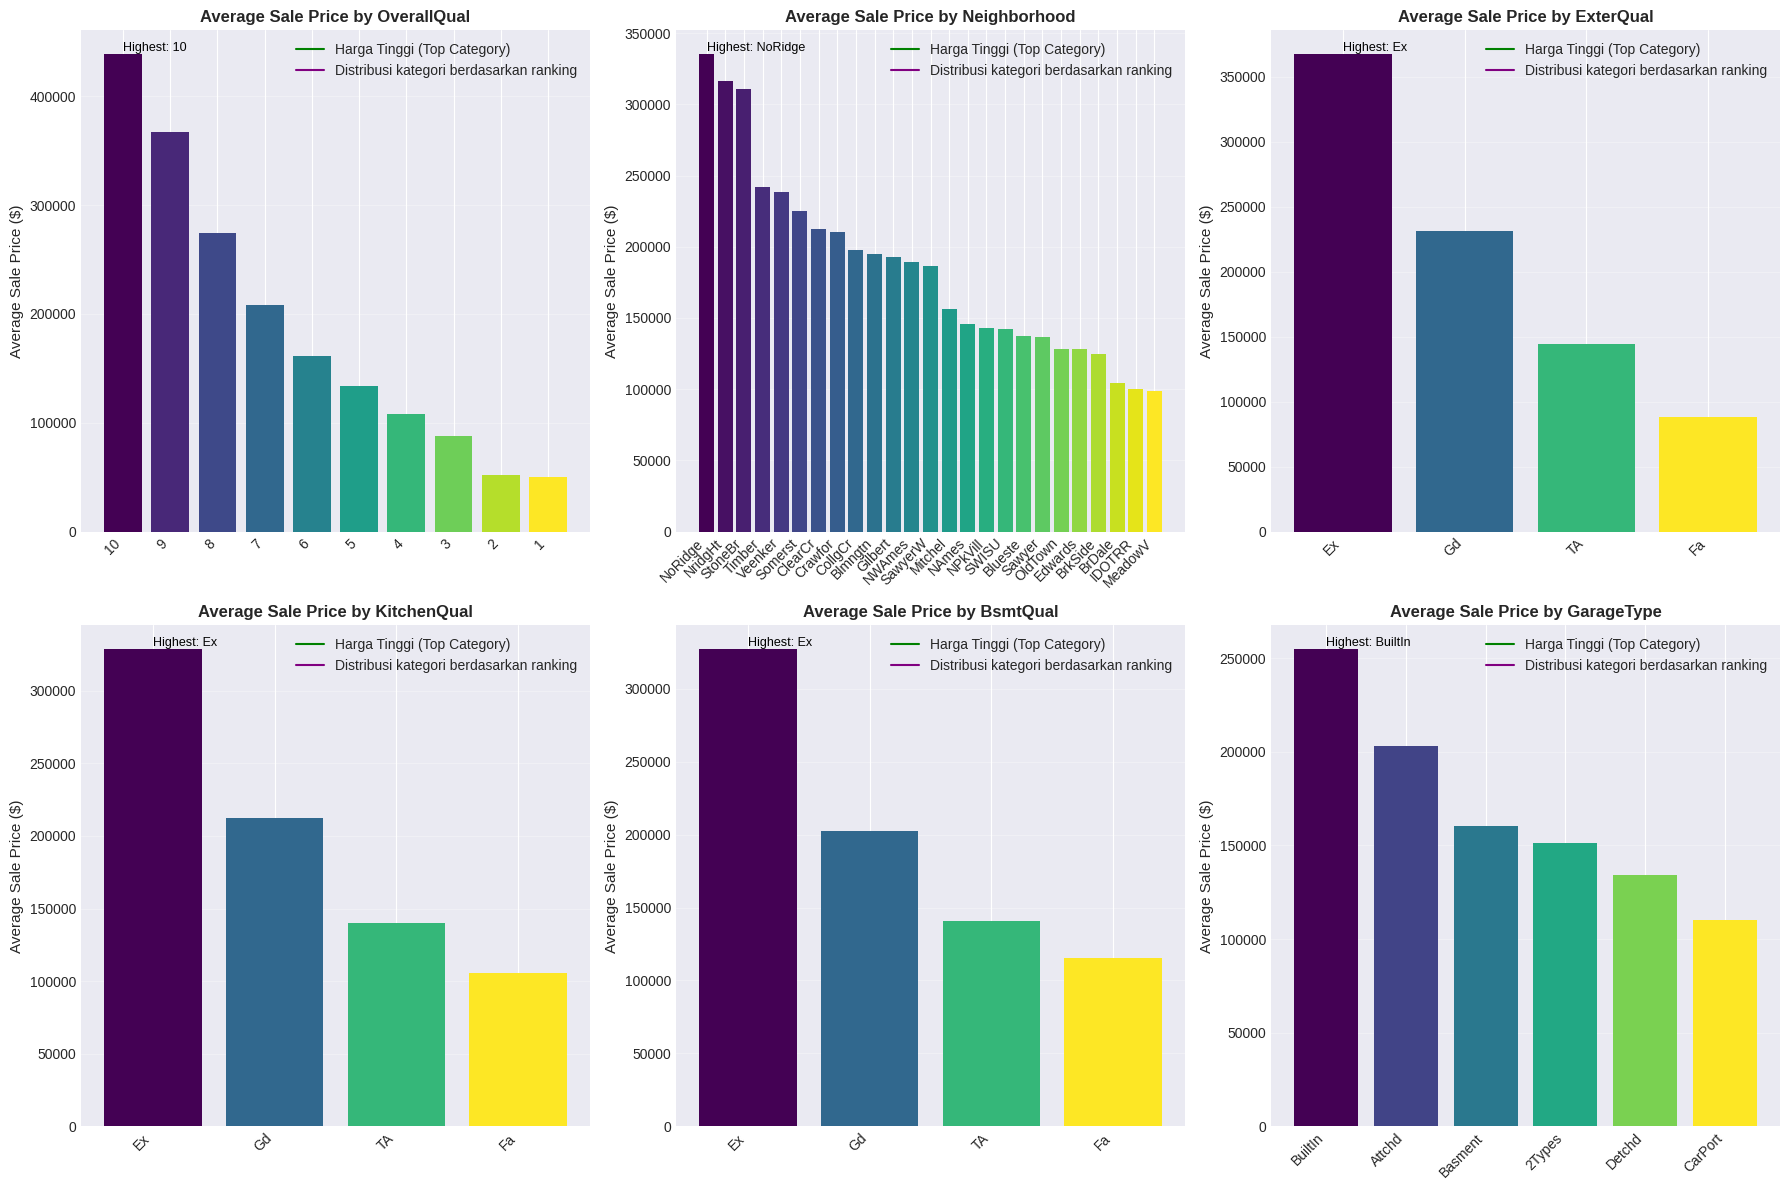

In [38]:
# Analisis top categorical features
important_categorical = ['OverallQual', 'Neighborhood', 'ExterQual', 'KitchenQual',
                         'BsmtQual', 'GarageType']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(important_categorical):
    if feature in df.columns:
        # Calculate mean price by category
        mean_prices = df.groupby(feature)['SalePrice'].mean().sort_values(ascending=False)

        # Warna berdasarkan ranking (tinggi = terang)
        colors = plt.cm.viridis(np.linspace(0, 1, len(mean_prices)))

        bars = axes[idx].bar(
            range(len(mean_prices)),
            mean_prices.values,
            color=colors
        )

        axes[idx].set_xticks(range(len(mean_prices)))
        axes[idx].set_xticklabels(mean_prices.index, rotation=45, ha='right')
        axes[idx].set_ylabel('Average Sale Price ($)', fontsize=11)
        axes[idx].set_title(f'Average Sale Price by {feature}',
                           fontsize=12, fontweight='bold')


        top_category = mean_prices.index[0]
        top_value = mean_prices.iloc[0]

        axes[idx].text(
            0,
            top_value,
            f'Highest: {top_category}',
            fontsize=9,
            color='black',
            ha='left',
            va='bottom'
        )

        axes[idx].plot([], [], color='green', label='Harga Tinggi (Top Category)')
        axes[idx].plot([], [], color='purple', label='Distribusi kategori berdasarkan ranking')

        axes[idx].legend()
        axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.5 Deteksi Outliers


 DETEKSI OUTLIERS (IQR Method)
    Feature  N_Outliers Percentage Lower_Bound Upper_Bound
OverallQual           2      0.14%        2.00       10.00
  GrLivArea          31      2.12%      158.62     2747.62
 GarageCars           5      0.34%       -0.50        3.50
 GarageArea          21      1.44%      -27.75      938.25
TotalBsmtSF          61      4.18%       42.00     2052.00
   1stFlrSF          20      1.37%      118.12     2155.12
  SalePrice          61      4.18%     3937.50   340037.50


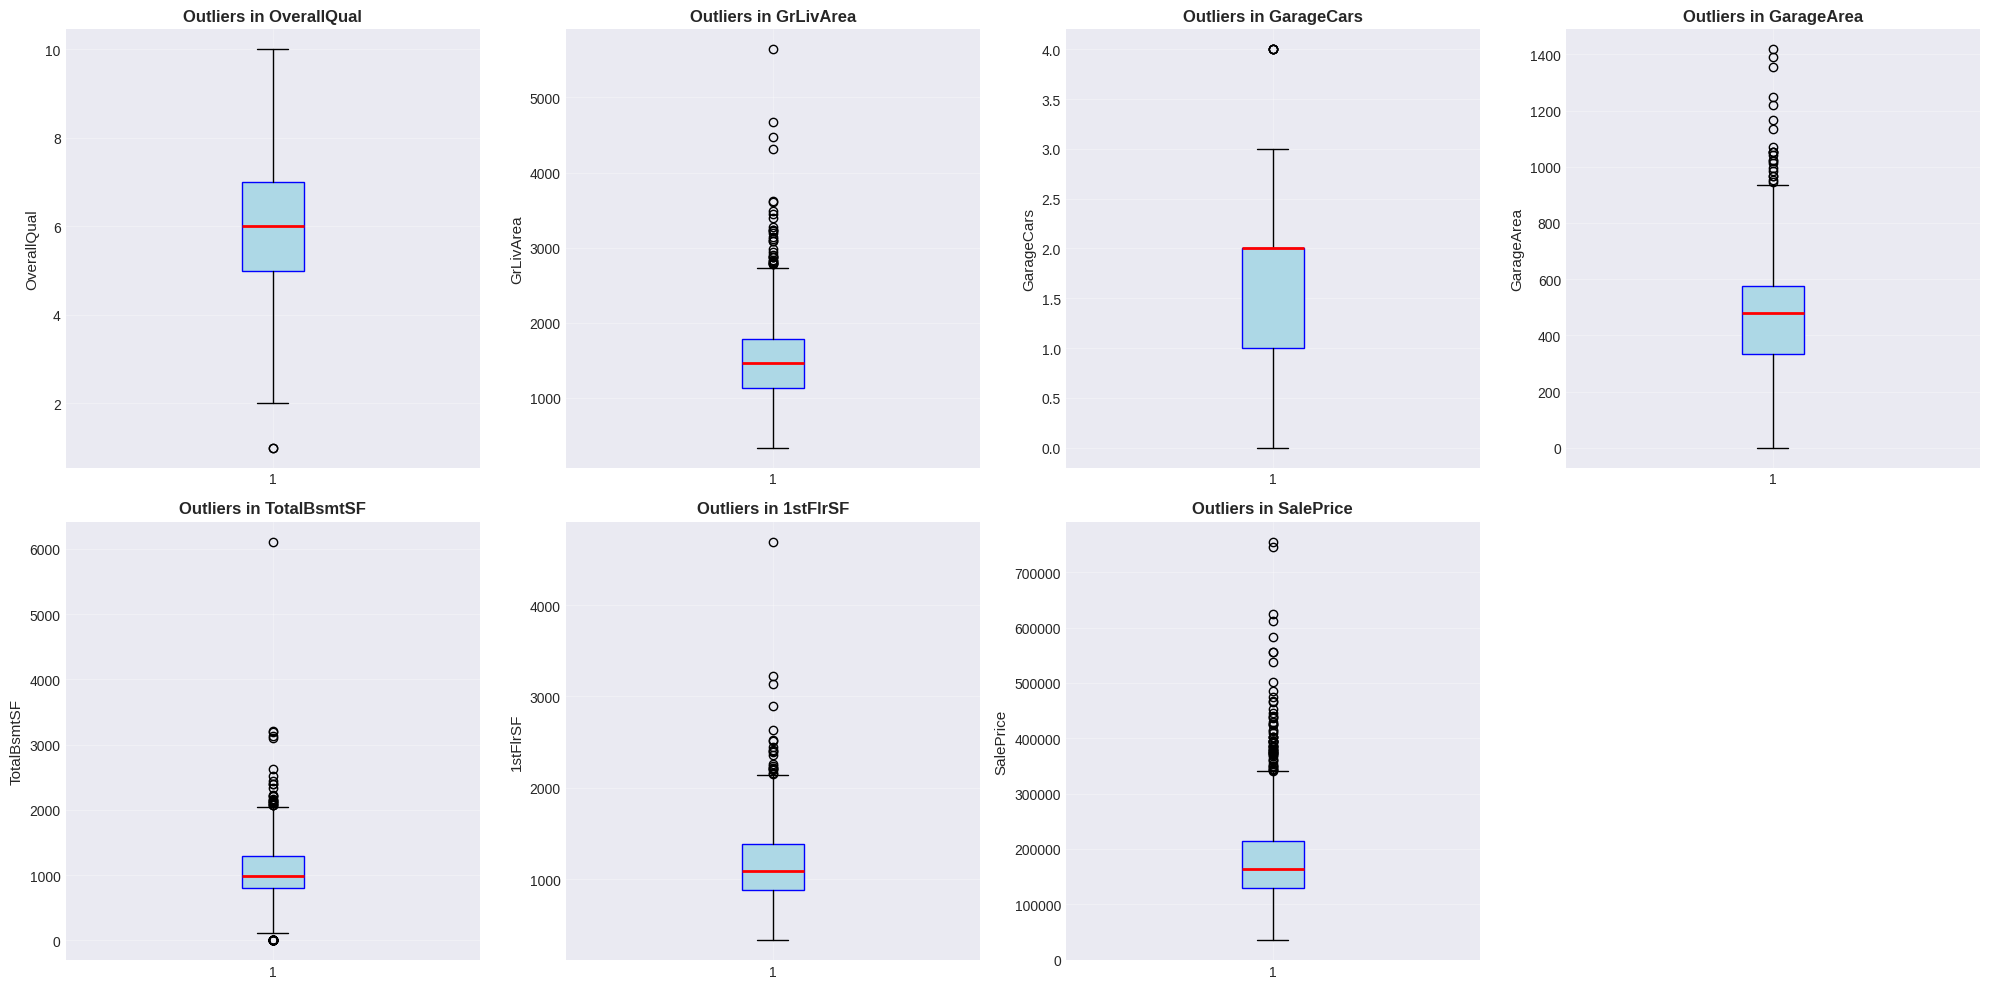

In [39]:
# Deteksi outliers menggunakan IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Analisis outliers untuk top numeric features
print("\n DETEKSI OUTLIERS (IQR Method)")
print("="*80)

outlier_summary = []
for feature in top_6_features + ['SalePrice']:
    n_outliers, lower, upper = detect_outliers_iqr(df, feature)
    pct_outliers = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Feature': feature,
        'N_Outliers': n_outliers,
        'Percentage': f'{pct_outliers:.2f}%',
        'Lower_Bound': f'{lower:.2f}',
        'Upper_Bound': f'{upper:.2f}'
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# Visualisasi outliers
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_6_features + ['SalePrice']):
    axes[idx].boxplot(df[feature].dropna(), vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='blue'),
                      medianprops=dict(color='red', linewidth=2))
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].set_title(f'Outliers in {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

# Hide extra subplot
axes[7].axis('off')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Handling Missing Values

In [40]:
df_processed = df.copy()

print("="*80)
print("HANDLING MISSING VALUES")
print("="*80)

# Untuk features
none_features = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
                 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

for feature in none_features:
    if feature in df_processed.columns:
        df_processed[feature].fillna('None', inplace=True)
        print(f"✓ {feature}: Filled NA with 'None'")

# Untuk numeric features, isi dengan median
numeric_na_features = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
for feature in numeric_na_features:
    if feature in df_processed.columns:
        median_value = df_processed[feature].median()
        df_processed[feature].fillna(median_value, inplace=True)
        print(f"✓ {feature}: Filled NA with median ({median_value:.2f})")

# Untuk categorical lainnya, isi dengan mode
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype == 'object':
            mode_value = df_processed[col].mode()[0]
            df_processed[col].fillna(mode_value, inplace=True)
            print(f"✓ {col}: Filled NA with mode ('{mode_value}')")
        else:
            median_value = df_processed[col].median()
            df_processed[col].fillna(median_value, inplace=True)
            print(f"✓ {col}: Filled NA with median ({median_value:.2f})")

print(f"\n Missing values setelah handling: {df_processed.isnull().sum().sum()}")

HANDLING MISSING VALUES
✓ Alley: Filled NA with 'None'
✓ BsmtQual: Filled NA with 'None'
✓ BsmtCond: Filled NA with 'None'
✓ BsmtExposure: Filled NA with 'None'
✓ BsmtFinType1: Filled NA with 'None'
✓ BsmtFinType2: Filled NA with 'None'
✓ FireplaceQu: Filled NA with 'None'
✓ GarageType: Filled NA with 'None'
✓ GarageFinish: Filled NA with 'None'
✓ GarageQual: Filled NA with 'None'
✓ GarageCond: Filled NA with 'None'
✓ PoolQC: Filled NA with 'None'
✓ Fence: Filled NA with 'None'
✓ MiscFeature: Filled NA with 'None'
✓ LotFrontage: Filled NA with median (69.00)
✓ MasVnrArea: Filled NA with median (0.00)
✓ GarageYrBlt: Filled NA with median (1980.00)
✓ MasVnrType: Filled NA with mode ('BrkFace')
✓ Electrical: Filled NA with mode ('SBrkr')

 Missing values setelah handling: 0


### 4.2 Feature Encoding

In [41]:
print("\n" + "="*80)
print(" FEATURE ENCODING - MANUAL LABEL ENCODING")
print("="*80)

# Identify categorical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"\nTotal categorical features: {len(categorical_cols)}")


encoding_mappings = {}  # Untuk menyimpan mapping setiap kolom

for col in categorical_cols:
    # Dapatkan unique values dari kolom
    unique_values = df_processed[col].astype(str).unique()

    # Buat mapping: setiap unique value mendapat angka berurutan mulai dari 0
    mapping = {value: idx for idx, value in enumerate(sorted(unique_values))}

    # Simpan mapping untuk referensi
    encoding_mappings[col] = mapping

    # Apply mapping ke kolom
    df_processed[col] = df_processed[col].astype(str).map(mapping)

    print(f"✓ {col}: Encoded manually ({len(mapping)} unique values)")

print(f"\n Total {len(categorical_cols)} categorical features berhasil di-encode secara manual!")

# Verifikasi: pastikan tidak ada non-numeric columns
print(f"\nVerifikasi tipe data:")
print(df_processed.dtypes.value_counts())

# Tampilkan contoh mapping untuk 3 kolom pertama
print(f"\nContoh Encoding Mapping (3 kolom pertama):")
for i, (col, mapping) in enumerate(list(encoding_mappings.items())[:3]):
    print(f"\n{col}:")
    print(f"  {dict(list(mapping.items())[:5])}...")


 FEATURE ENCODING - MANUAL LABEL ENCODING

Total categorical features: 43
✓ MSZoning: Encoded manually (5 unique values)
✓ Street: Encoded manually (2 unique values)
✓ Alley: Encoded manually (3 unique values)
✓ LotShape: Encoded manually (4 unique values)
✓ LandContour: Encoded manually (4 unique values)
✓ Utilities: Encoded manually (2 unique values)
✓ LotConfig: Encoded manually (5 unique values)
✓ LandSlope: Encoded manually (3 unique values)
✓ Neighborhood: Encoded manually (25 unique values)
✓ Condition1: Encoded manually (9 unique values)
✓ Condition2: Encoded manually (8 unique values)
✓ BldgType: Encoded manually (5 unique values)
✓ HouseStyle: Encoded manually (8 unique values)
✓ RoofStyle: Encoded manually (6 unique values)
✓ RoofMatl: Encoded manually (8 unique values)
✓ Exterior1st: Encoded manually (15 unique values)
✓ Exterior2nd: Encoded manually (16 unique values)
✓ MasVnrType: Encoded manually (3 unique values)
✓ ExterQual: Encoded manually (4 unique values)
✓ ExterC

## 5. Feature Engineering

 FEATURE ENGINEERING
 Created: TotalSF (Total Square Footage)
 Created: HouseAge
 Created: RemodelAge
 Created: TotalBath
 Created: TotalPorchSF
 Created: HasPool
 Created: HasGarage
 Created: HasBsmt
 Created: HasFireplace
 Created: QualityScore

 Total new features created: 10
Total features sekarang: 90


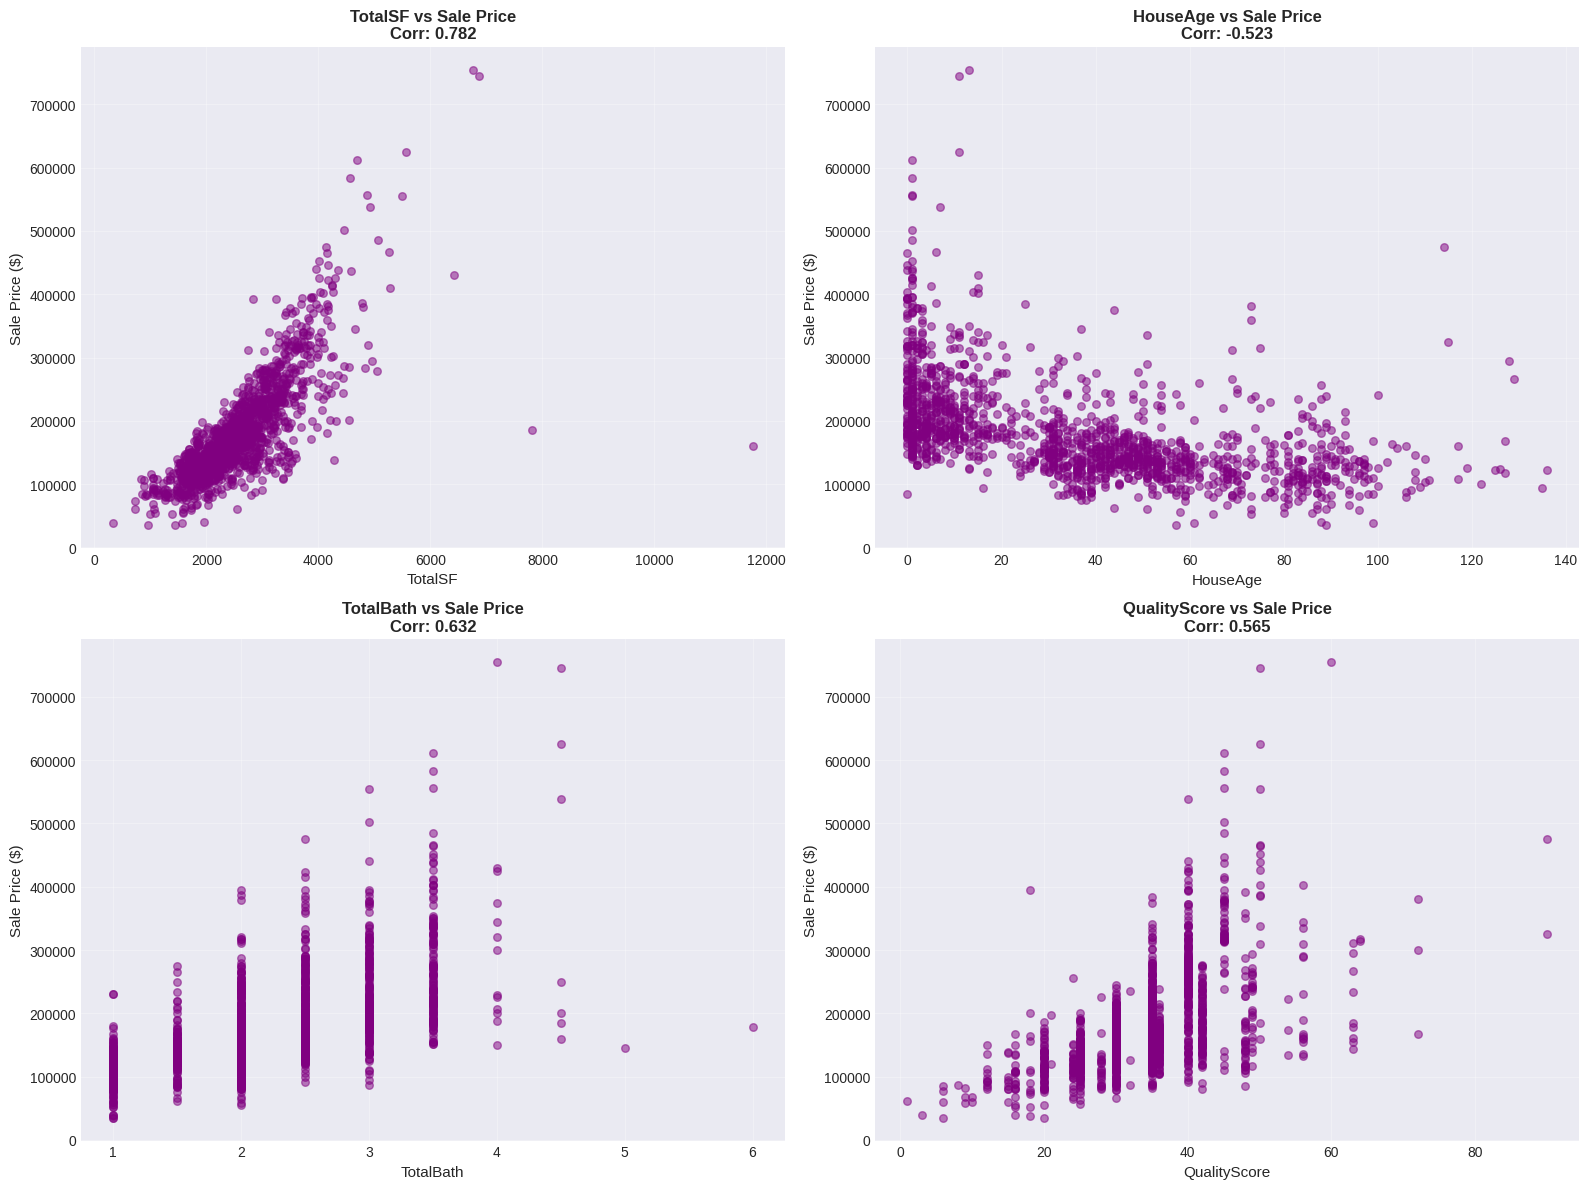


RINGKASAN FEATURE ENGINEERING
   Feature Baru                                              Rumus  \
0       TotalSF                  TotalBsmtSF + 1stFlrSF + 2ndFlrSF   
1      HouseAge                                 YrSold - YearBuilt   
2    RemodelAge                              YrSold - YearRemodAdd   
3     TotalBath  FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*B...   
4  TotalPorchSF  OpenPorchSF + EnclosedPorch + 3SsnPorch + Scre...   
5       HasPool                                     (PoolArea > 0)   
6     HasGarage                                   (GarageArea > 0)   
7       HasBsmt                                  (TotalBsmtSF > 0)   
8  HasFireplace                                   (Fireplaces > 0)   
9  QualityScore                          OverallQual * OverallCond   

             Deskripsi  
0     Total luas rumah  
1           Umur rumah  
2  Umur sejak renovasi  
3    Total kamar mandi  
4     Total luas teras  
5      Ada kolam (1/0)  
6     Ada garasi (1/0) 

In [63]:
print("="*80)
print(" FEATURE ENGINEERING")
print("="*80)

# 1. Total Square Footage
df_processed['TotalSF'] = df_processed['TotalBsmtSF'] + df_processed['1stFlrSF'] + df_processed['2ndFlrSF']
print(" Created: TotalSF (Total Square Footage)")

# 2. House Age
df_processed['HouseAge'] = df_processed['YrSold'] - df_processed['YearBuilt']
print(" Created: HouseAge")

# 3. Remodel Age
df_processed['RemodelAge'] = df_processed['YrSold'] - df_processed['YearRemodAdd']
print(" Created: RemodelAge")

# 4. Total Bathrooms
df_processed['TotalBath'] = (df_processed['FullBath'] +
                             0.5 * df_processed['HalfBath'] +
                             df_processed['BsmtFullBath'] +
                             0.5 * df_processed['BsmtHalfBath'])
print(" Created: TotalBath")

# 5. Total Porch SF
df_processed['TotalPorchSF'] = (df_processed['OpenPorchSF'] +
                                df_processed['EnclosedPorch'] +
                                df_processed['3SsnPorch'] +
                                df_processed['ScreenPorch'])
print(" Created: TotalPorchSF")

# 6. Has Pool
df_processed['HasPool'] = (df_processed['PoolArea'] > 0).astype(int)
print(" Created: HasPool")

# 7. Has Garage
df_processed['HasGarage'] = (df_processed['GarageArea'] > 0).astype(int)
print(" Created: HasGarage")

# 8. Has Basement
df_processed['HasBsmt'] = (df_processed['TotalBsmtSF'] > 0).astype(int)
print(" Created: HasBsmt")

# 9. Has Fireplace
df_processed['HasFireplace'] = (df_processed['Fireplaces'] > 0).astype(int)
print(" Created: HasFireplace")

# 10. Quality Score (kombinasi OverallQual dan OverallCond)
df_processed['QualityScore'] = df_processed['OverallQual'] * df_processed['OverallCond']
print(" Created: QualityScore")

print(f"\n Total new features created: 10")
print(f"Total features sekarang: {df_processed.shape[1]}")

# Visualisasi new features vs SalePrice
new_features = ['TotalSF', 'HouseAge', 'TotalBath', 'QualityScore']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, feature in enumerate(new_features):
    axes[idx].scatter(df_processed[feature], df_processed['SalePrice'],
                     alpha=0.5, s=30, color='purple')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Sale Price ($)', fontsize=11)

    # Calculate correlation
    corr = df_processed[[feature, 'SalePrice']].corr().iloc[0, 1]
    axes[idx].set_title(f'{feature} vs Sale Price\nCorr: {corr:.3f}',
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===============================
# TABEL FEATURE ENGINEERING
# ===============================
import pandas as pd

feature_engineering_summary = pd.DataFrame({
    'Feature Baru': [
        'TotalSF',
        'HouseAge',
        'RemodelAge',
        'TotalBath',
        'TotalPorchSF',
        'HasPool',
        'HasGarage',
        'HasBsmt',
        'HasFireplace',
        'QualityScore'
    ],
    'Rumus': [
        'TotalBsmtSF + 1stFlrSF + 2ndFlrSF',
        'YrSold - YearBuilt',
        'YrSold - YearRemodAdd',
        'FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath',
        'OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch',
        '(PoolArea > 0)',
        '(GarageArea > 0)',
        '(TotalBsmtSF > 0)',
        '(Fireplaces > 0)',
        'OverallQual * OverallCond'
    ],
    'Deskripsi': [
        'Total luas rumah',
        'Umur rumah',
        'Umur sejak renovasi',
        'Total kamar mandi',
        'Total luas teras',
        'Ada kolam (1/0)',
        'Ada garasi (1/0)',
        'Ada basement (1/0)',
        'Ada fireplace (1/0)',
        'Skor kualitas rumah'
    ]
})

print("\n" + "="*80)
print("RINGKASAN FEATURE ENGINEERING")
print("="*80)

print(feature_engineering_summary)

In [59]:
import pandas as pd

# Membuat ringkasan feature engineering dalam bentuk tabel
feature_engineering_summary = pd.DataFrame({
    'Feature Baru': [
        'TotalSF',
        'HouseAge',
        'RemodelAge',
        'TotalBath',
        'TotalPorchSF',
        'HasPool',
        'HasGarage',
        'HasBsmt',
        'HasFireplace',
        'QualityScore'
    ],
    'Rumus / Cara Hitung': [
        'TotalBsmtSF + 1stFlrSF + 2ndFlrSF',
        'YrSold - YearBuilt',
        'YrSold - YearRemodAdd',
        'FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath',
        'OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch',
        '(PoolArea > 0)',
        '(GarageArea > 0)',
        '(TotalBsmtSF > 0)',
        '(Fireplaces > 0)',
        'OverallQual * OverallCond'
    ],
    'Deskripsi': [
        'Total luas rumah',
        'Umur rumah saat dijual',
        'Umur sejak renovasi terakhir',
        'Total kamar mandi (full + half)',
        'Total luas area teras',
        'Ada kolam renang (1/0)',
        'Ada garasi (1/0)',
        'Ada basement (1/0)',
        'Ada fireplace (1/0)',
        'Skor gabungan kualitas & kondisi'
    ]
})

# Tampilkan tabel
print(feature_engineering_summary)

   Feature Baru                                Rumus / Cara Hitung  \
0       TotalSF                  TotalBsmtSF + 1stFlrSF + 2ndFlrSF   
1      HouseAge                                 YrSold - YearBuilt   
2    RemodelAge                              YrSold - YearRemodAdd   
3     TotalBath  FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*B...   
4  TotalPorchSF  OpenPorchSF + EnclosedPorch + 3SsnPorch + Scre...   
5       HasPool                                     (PoolArea > 0)   
6     HasGarage                                   (GarageArea > 0)   
7       HasBsmt                                  (TotalBsmtSF > 0)   
8  HasFireplace                                   (Fireplaces > 0)   
9  QualityScore                          OverallQual * OverallCond   

                          Deskripsi  
0                  Total luas rumah  
1            Umur rumah saat dijual  
2      Umur sejak renovasi terakhir  
3   Total kamar mandi (full + half)  
4             Total luas area teras  
5

### 5.1 Train-Test Split dan Feature Scaling

In [43]:
print("="*80)
print(" TRAIN-TEST SPLIT & FEATURE SCALING")
print("="*80)

# Drop Id column
if 'Id' in df_processed.columns:
    df_processed.drop('Id', axis=1, inplace=True)

# Separate features and target
X = df_processed.drop('SalePrice', axis=1)
y = df_processed['SalePrice']

print(f"\n Dimensi Data:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\nData Split (80-20):")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\nFeature scaling completed using StandardScaler")
print(f"\nScaled feature statistics (training set):")
print(f"Mean: {X_train_scaled.mean().mean():.6f}")
print(f"Std: {X_train_scaled.std().mean():.6f}")

 TRAIN-TEST SPLIT & FEATURE SCALING

 Dimensi Data:
Features (X): (1460, 89)
Target (y): (1460,)

Data Split (80-20):
Training set: 1022 samples (70.0%)
Testing set: 438 samples (30.0%)

Feature scaling completed using StandardScaler

Scaled feature statistics (training set):
Mean: 0.000000
Std: 1.000490


## 6. Model 1: Multiple Linear Regression (Baseline)

In [44]:
print("="*80)
print("MODEL 1: MULTIPLE LINEAR REGRESSION (BASELINE)")
print("="*80)

# Initialize and train model
start_time = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.4f} seconds")

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation metrics
def calculate_metrics(y_true, y_pred, dataset_name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n {dataset_name} Metrics:")
    print(f"  R² Score    : {r2:.6f}")
    print(f"  RMSE        : ${rmse:,.2f}")
    print(f"  MAE         : ${mae:,.2f}")
    print(f"  MAPE        : {mape:.2f}%")

    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

lr_train_metrics = calculate_metrics(y_train, y_train_pred_lr, "Training Set")
lr_test_metrics = calculate_metrics(y_test, y_test_pred_lr, "Testing Set")

# Cross-validation
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train,
                            cv=5, scoring='r2')
print(f"\n  5-Fold Cross-Validation R² Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.6f}")
print(f"  Mean CV R²: {cv_scores.mean():.6f} (+/- {cv_scores.std() * 2:.6f})")

MODEL 1: MULTIPLE LINEAR REGRESSION (BASELINE)

Training time: 0.6578 seconds

 Training Set Metrics:
  R² Score    : 0.885121
  RMSE        : $26,294.62
  MAE         : $17,317.35
  MAPE        : 10.24%

 Testing Set Metrics:
  R² Score    : 0.818874
  RMSE        : $35,551.55
  MAE         : $20,991.30
  MAPE        : 12.59%

  5-Fold Cross-Validation R² Scores:
  Fold 1: 0.884912
  Fold 2: 0.655517
  Fold 3: 0.859363
  Fold 4: 0.821089
  Fold 5: 0.055126
  Mean CV R²: 0.655201 (+/- 0.621005)


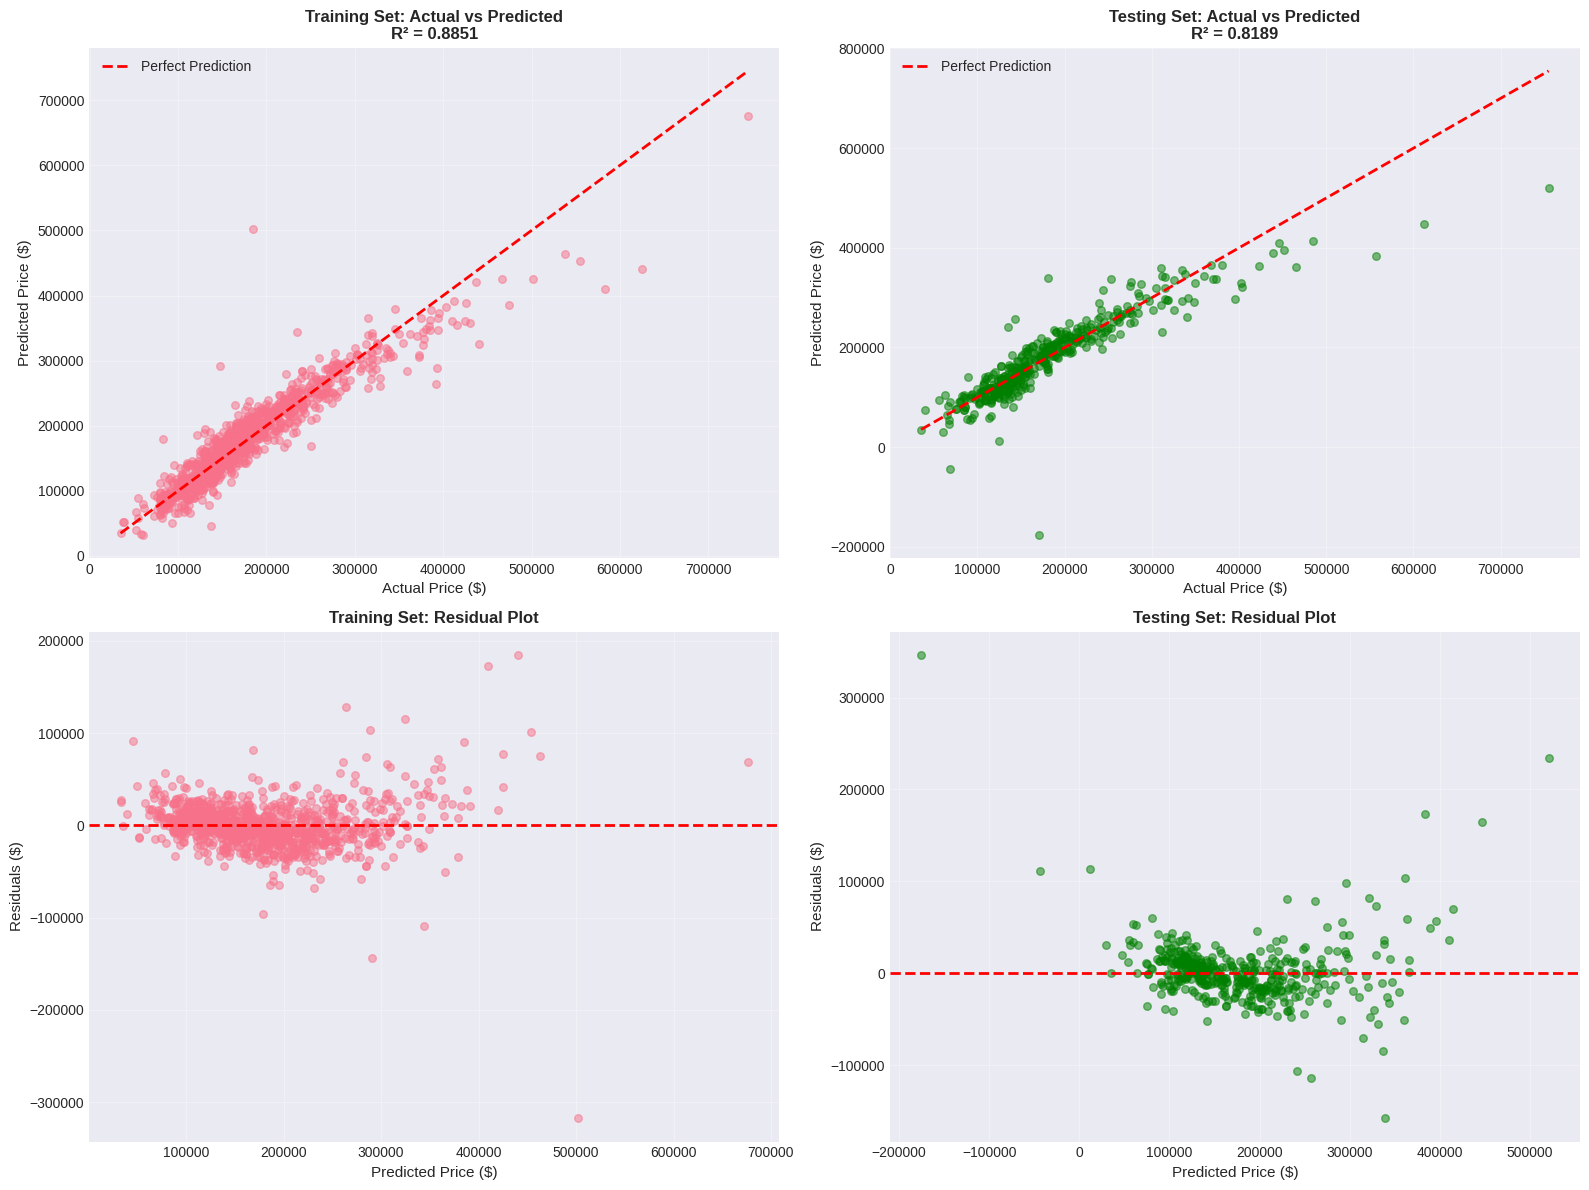

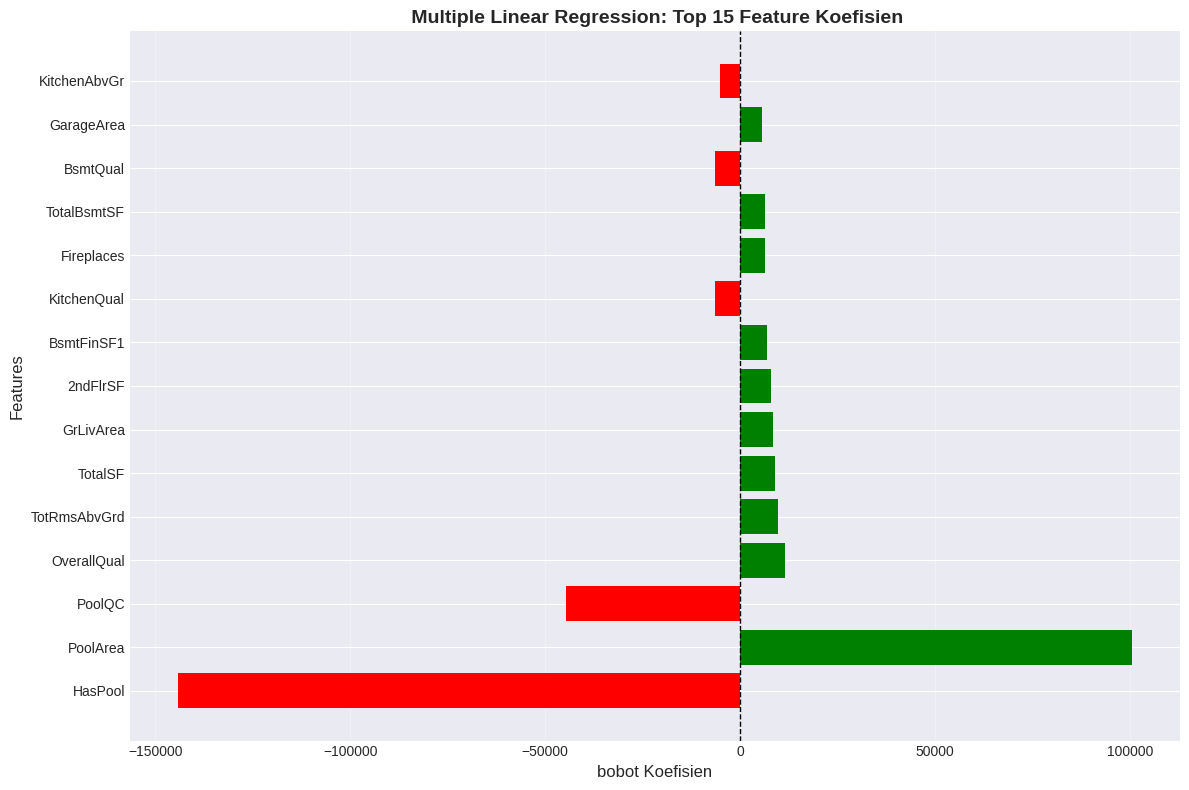


 Top 15 Most Important Features (by coefficient magnitude):
     Feature    Coefficient
     HasPool -144255.581345
    PoolArea  100512.374439
      PoolQC  -44725.192170
 OverallQual   11438.839489
TotRmsAbvGrd    9756.345912
     TotalSF    8806.790344
   GrLivArea    8335.183533
    2ndFlrSF    7787.542236
  BsmtFinSF1    6752.561635
 KitchenQual   -6401.822188
  Fireplaces    6389.205263
 TotalBsmtSF    6380.929077
    BsmtQual   -6352.014074
  GarageArea    5651.248269
KitchenAbvGr   -5235.074021


In [65]:
# Visualisasi Linear Regression Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Training)
axes[0, 0].scatter(y_train, y_train_pred_lr, alpha=0.5, s=30)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {lr_train_metrics["R2"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Actual vs Predicted (Testing)
axes[0, 1].scatter(y_test, y_test_pred_lr, alpha=0.5, s=30, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 1].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0, 1].set_title(f'Testing Set: Actual vs Predicted\nR² = {lr_test_metrics["R2"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Residual Plot (Training)
residuals_train = y_train - y_train_pred_lr
axes[1, 0].scatter(y_train_pred_lr, residuals_train, alpha=0.5, s=30)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price ($)', fontsize=11)
axes[1, 0].set_ylabel('Residuals ($)', fontsize=11)
axes[1, 0].set_title('Training Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Residual Plot (Testing)
residuals_test = y_test - y_test_pred_lr
axes[1, 1].scatter(y_test_pred_lr, residuals_test, alpha=0.5, s=30, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Price ($)', fontsize=11)
axes[1, 1].set_ylabel('Residuals ($)', fontsize=11)
axes[1, 1].set_title('Testing Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance (Top 15 coefficients)
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.xlabel('bobot Koefisien', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title(' Multiple Linear Regression: Top 15 Feature Koefisien', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n Top 15 Most Important Features (by coefficient magnitude):")
print(feature_importance.to_string(index=False))

## 7. Model 2: Random Forest


In [67]:
print("="*80)
print("MODEL 2: RANDOM FOREST")
print("="*80)
# Initialize and train model (default parameters)
start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"\n Model Configuration:")
print(f"  Number of trees: {rf_model.n_estimators}")
print(f"  Max depth: {rf_model.max_depth}")
print(f"  Min samples split: {rf_model.min_samples_split}")
print(f"  Min samples leaf: {rf_model.min_samples_leaf}")

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
rf_train_metrics = calculate_metrics(y_train, y_train_pred_rf, "Training Set")
rf_test_metrics = calculate_metrics(y_test, y_test_pred_rf, "Testing Set")

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train, y_train,
                                cv=5, scoring='r2')
print(f"\n 5-Fold Cross-Validation R² Scores:")
for i, score in enumerate(cv_scores_rf, 1):
    print(f"  Fold {i}: {score:.6f}")
print(f"  Mean CV R²: {cv_scores_rf.mean():.6f} (+/- {cv_scores_rf.std() * 2:.6f})")

MODEL 2: RANDOM FOREST

 Model Configuration:
  Number of trees: 100
  Max depth: None
  Min samples split: 2
  Min samples leaf: 1

 Training Set Metrics:
  R² Score    : 0.977979
  RMSE        : $11,512.31
  MAE         : $6,528.54
  MAPE        : 3.76%

 Testing Set Metrics:
  R² Score    : 0.906504
  RMSE        : $25,542.61
  MAE         : $15,484.98
  MAPE        : 9.30%

 5-Fold Cross-Validation R² Scores:
  Fold 1: 0.867050
  Fold 2: 0.649024
  Fold 3: 0.873813
  Fold 4: 0.886166
  Fold 5: 0.876908
  Mean CV R²: 0.830592 (+/- 0.181985)


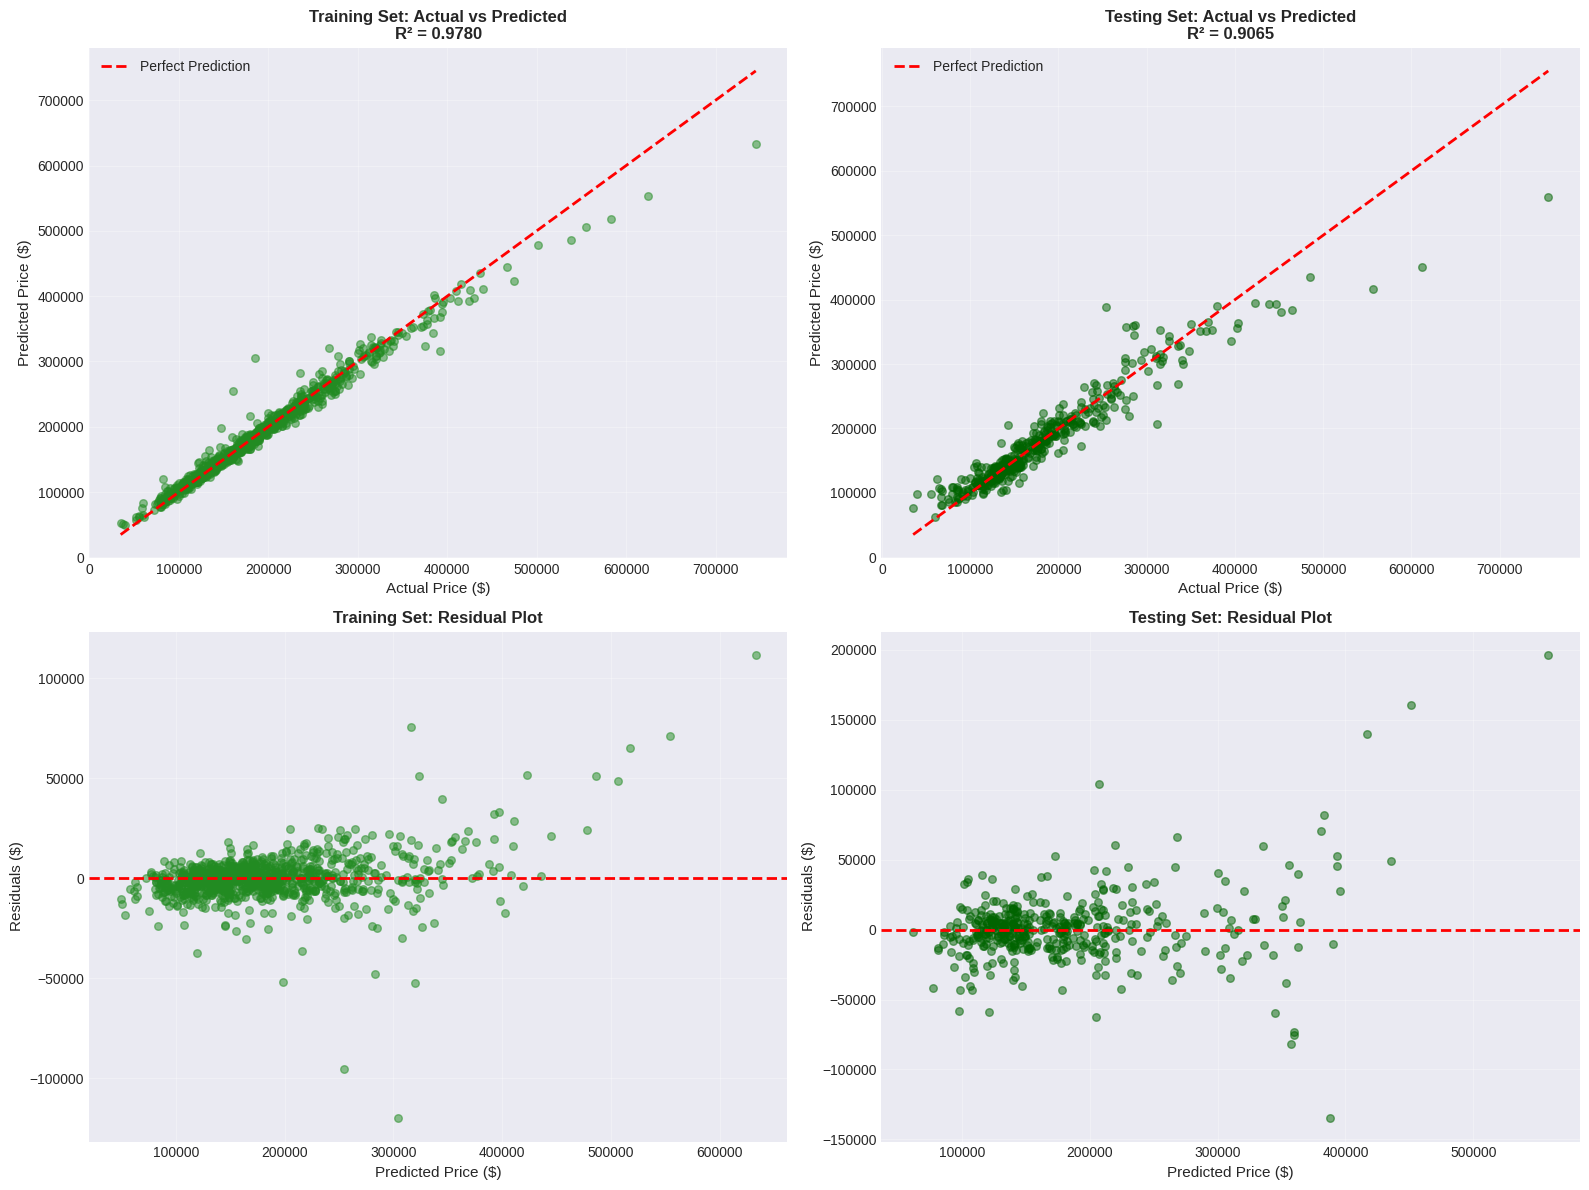

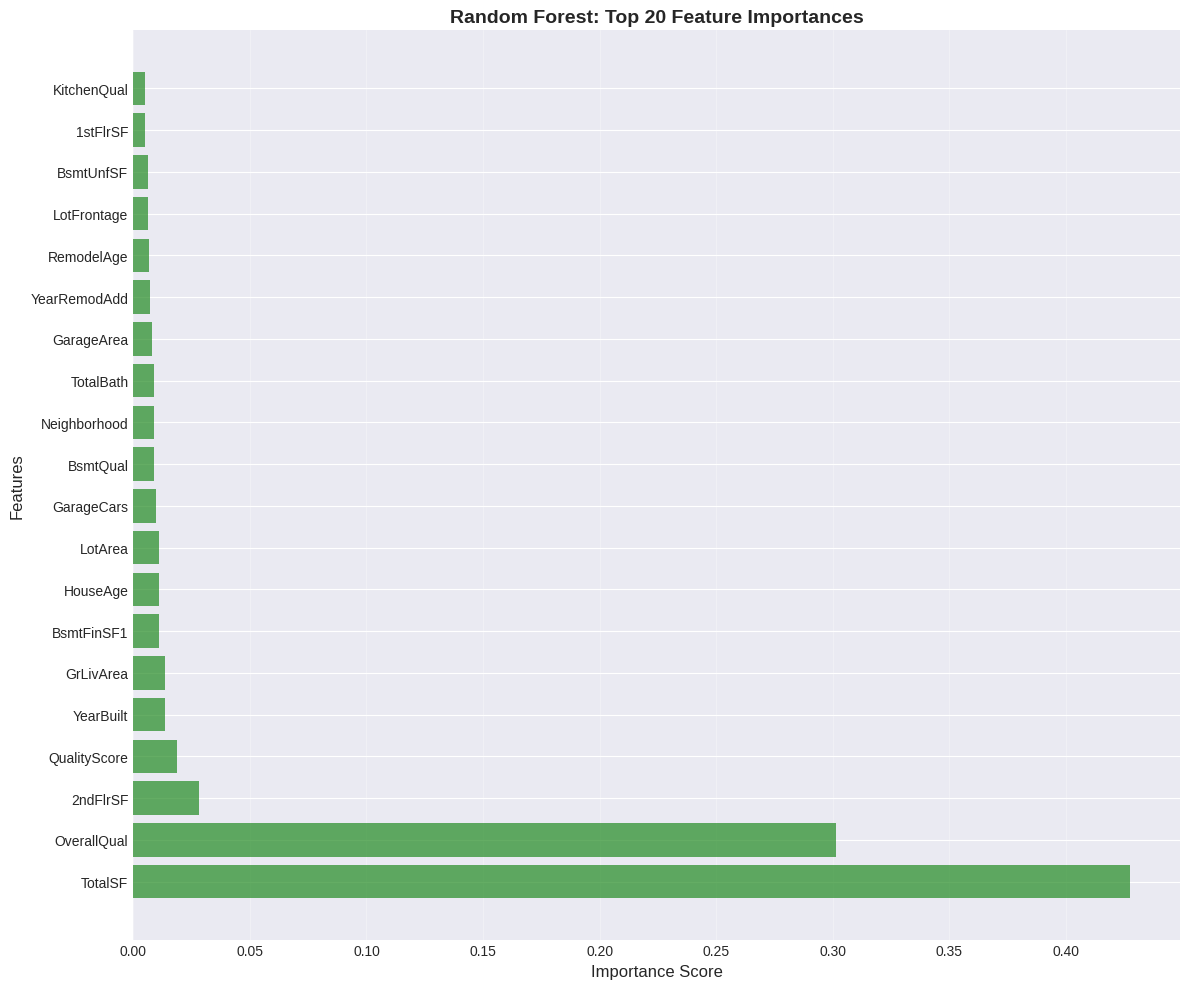


 Top 20 Most Important Features (Random Forest):
     Feature  Importance
     TotalSF    0.427528
 OverallQual    0.301459
    2ndFlrSF    0.028258
QualityScore    0.018628
   YearBuilt    0.013703
   GrLivArea    0.013536
  BsmtFinSF1    0.011148
    HouseAge    0.010987
     LotArea    0.010955
  GarageCars    0.009641
    BsmtQual    0.009025
Neighborhood    0.009005
   TotalBath    0.008771
  GarageArea    0.007937
YearRemodAdd    0.007007
  RemodelAge    0.006549
 LotFrontage    0.006385
   BsmtUnfSF    0.006099
    1stFlrSF    0.005170
 KitchenQual    0.004845


In [47]:
# Visualisasi Random Forest Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Training)
axes[0, 0].scatter(y_train, y_train_pred_rf, alpha=0.5, s=30, color='forestgreen')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {rf_train_metrics["R2"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Actual vs Predicted (Testing)
axes[0, 1].scatter(y_test, y_test_pred_rf, alpha=0.5, s=30, color='darkgreen')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 1].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0, 1].set_title(f'Testing Set: Actual vs Predicted\nR² = {rf_test_metrics["R2"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Residual Plot (Training)
residuals_train_rf = y_train - y_train_pred_rf
axes[1, 0].scatter(y_train_pred_rf, residuals_train_rf, alpha=0.5, s=30, color='forestgreen')
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price ($)', fontsize=11)
axes[1, 0].set_ylabel('Residuals ($)', fontsize=11)
axes[1, 0].set_title('Training Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Residual Plot (Testing)
residuals_test_rf = y_test - y_test_pred_rf
axes[1, 1].scatter(y_test_pred_rf, residuals_test_rf, alpha=0.5, s=30, color='darkgreen')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Price ($)', fontsize=11)
axes[1, 1].set_ylabel('Residuals ($)', fontsize=11)
axes[1, 1].set_title('Testing Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 10))
plt.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'],
         color='forestgreen', alpha=0.7)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Random Forest: Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n Top 20 Most Important Features (Random Forest):")
print(feature_importance_rf.to_string(index=False))

## 8. Model 3: XGBoost

In [48]:
print("="*80)
print("MODEL 3: XGBOOST REGRESSOR")
print("="*80)

# Initialize and train model (default parameters)
start_time = time.time()
# xgb_model = XGBRegressor(
#     n_estimators=100,
#     learning_rate=0.1,
#     random_state=42,
#     n_jobs=-1,
#     verbosity=0
# )

xgb_model= XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)
xgb_model.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.4f} seconds")
print(f"\nModel Configuration:")
print(f"  Number of estimators: {xgb_model.n_estimators}")
print(f"  Learning rate: {xgb_model.learning_rate}")
print(f"  Max depth: {xgb_model.max_depth}")
print(f"  Min child weight: {xgb_model.min_child_weight}")

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluation
xgb_train_metrics = calculate_metrics(y_train, y_train_pred_xgb, "Training Set")
xgb_test_metrics = calculate_metrics(y_test, y_test_pred_xgb, "Testing Set")

# Cross-validation
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train,
                                 cv=5, scoring='r2')
print(f"\n5-Fold Cross-Validation R² Scores:")
for i, score in enumerate(cv_scores_xgb, 1):
    print(f"  Fold {i}: {score:.6f}")
print(f"  Mean CV R²: {cv_scores_xgb.mean():.6f} (+/- {cv_scores_xgb.std() * 2:.6f})")

MODEL 3: XGBOOST REGRESSOR

Training time: 3.5204 seconds

Model Configuration:
  Number of estimators: 300
  Learning rate: 0.05
  Max depth: 6
  Min child weight: 3

 Training Set Metrics:
  R² Score    : 0.997158
  RMSE        : $4,135.45
  MAE         : $3,021.71
  MAPE        : 1.93%

 Testing Set Metrics:
  R² Score    : 0.928774
  RMSE        : $22,293.96
  MAE         : $14,356.62
  MAPE        : 8.68%

5-Fold Cross-Validation R² Scores:
  Fold 1: 0.865705
  Fold 2: 0.620703
  Fold 3: 0.853465
  Fold 4: 0.878235
  Fold 5: 0.894350
  Mean CV R²: 0.822492 (+/- 0.203600)


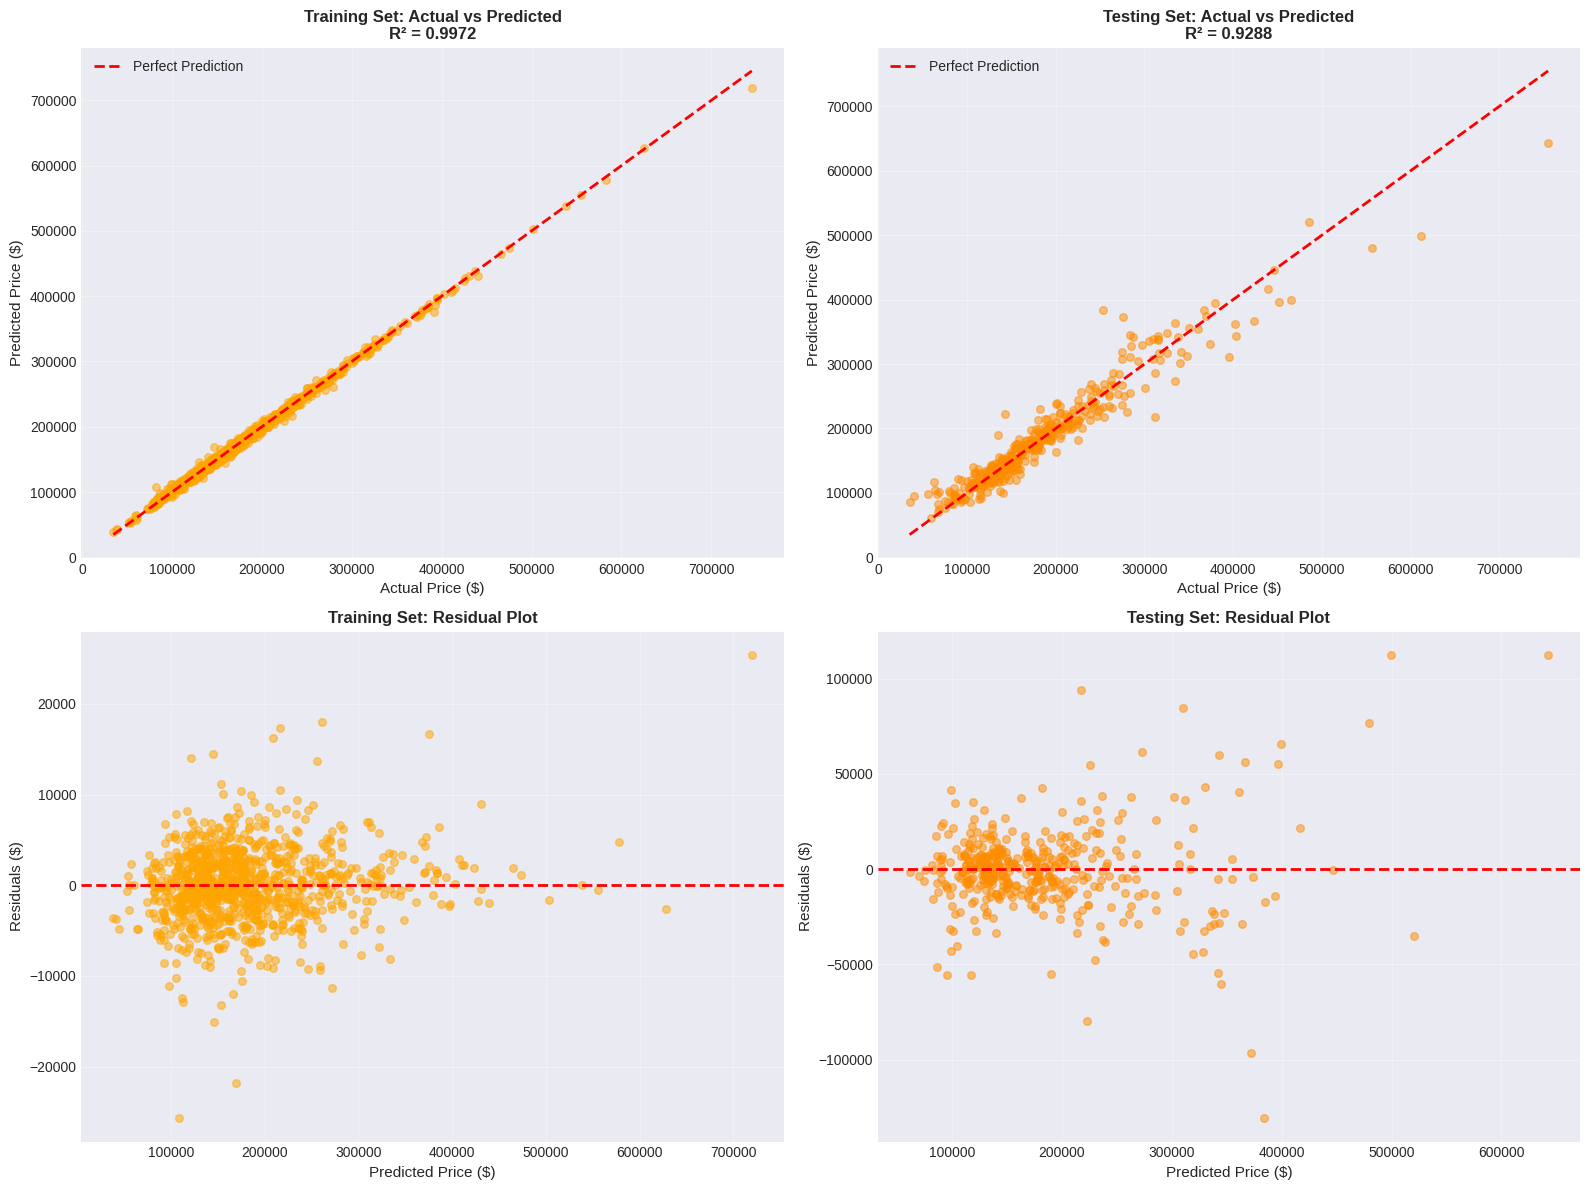

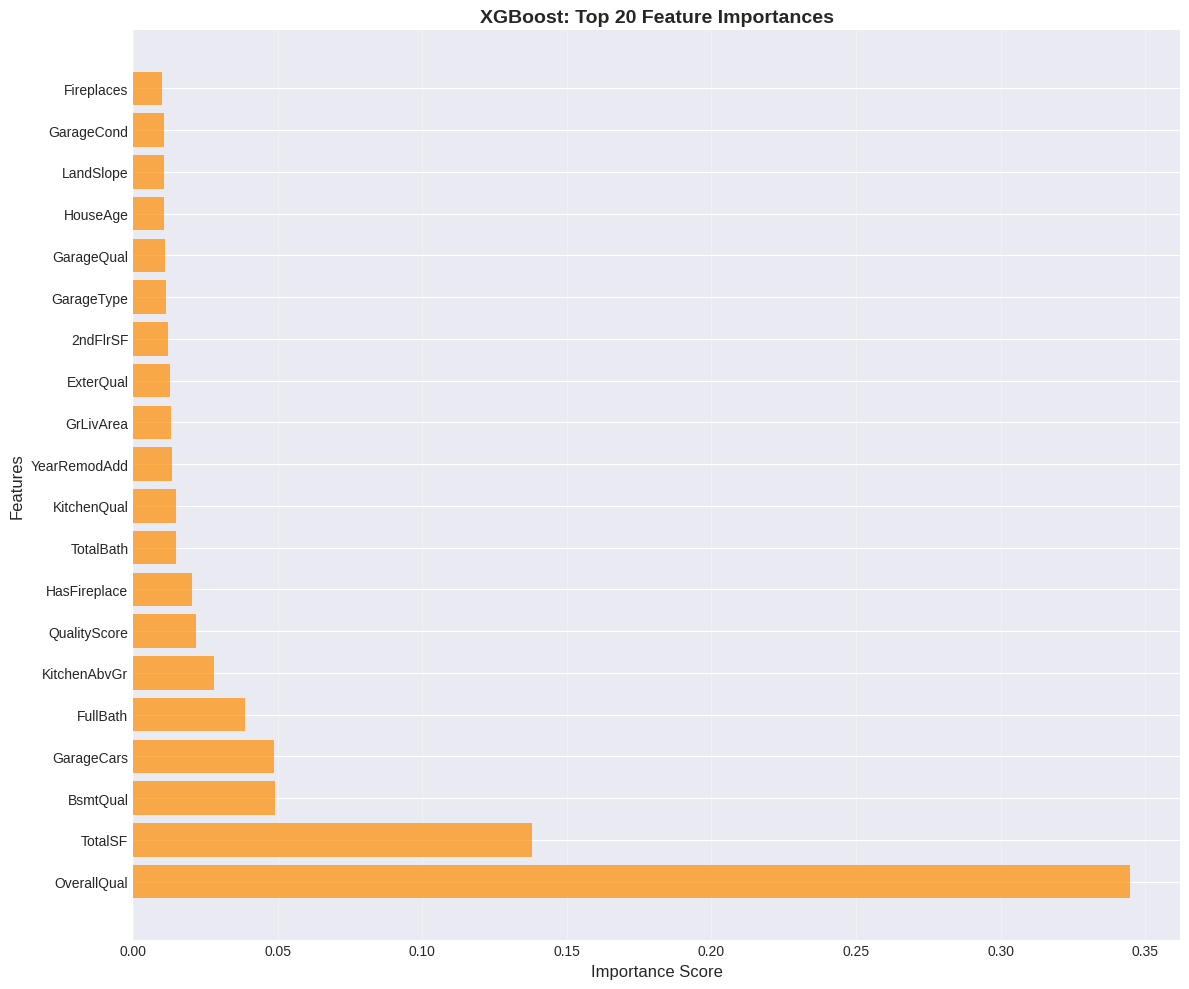


 Top 20 Most Important Features (XGBoost):
     Feature  Importance
 OverallQual    0.344821
     TotalSF    0.137823
    BsmtQual    0.049119
  GarageCars    0.048516
    FullBath    0.038543
KitchenAbvGr    0.027961
QualityScore    0.021595
HasFireplace    0.020194
   TotalBath    0.014755
 KitchenQual    0.014731
YearRemodAdd    0.013279
   GrLivArea    0.013127
   ExterQual    0.012624
    2ndFlrSF    0.011911
  GarageType    0.011229
  GarageQual    0.011089
    HouseAge    0.010776
   LandSlope    0.010594
  GarageCond    0.010562
  Fireplaces    0.009857


In [49]:
# Visualisasi XGBoost Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Training)
axes[0, 0].scatter(y_train, y_train_pred_xgb, alpha=0.5, s=30, color='orange')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {xgb_train_metrics["R2"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Actual vs Predicted (Testing)
axes[0, 1].scatter(y_test, y_test_pred_xgb, alpha=0.5, s=30, color='darkorange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 1].set_ylabel('Predicted Price ($)', fontsize=11)
axes[0, 1].set_title(f'Testing Set: Actual vs Predicted\nR² = {xgb_test_metrics["R2"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Residual Plot (Training)
residuals_train_xgb = y_train - y_train_pred_xgb
axes[1, 0].scatter(y_train_pred_xgb, residuals_train_xgb, alpha=0.5, s=30, color='orange')
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price ($)', fontsize=11)
axes[1, 0].set_ylabel('Residuals ($)', fontsize=11)
axes[1, 0].set_title('Training Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Residual Plot (Testing)
residuals_test_xgb = y_test - y_test_pred_xgb
axes[1, 1].scatter(y_test_pred_xgb, residuals_test_xgb, alpha=0.5, s=30, color='darkorange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Price ($)', fontsize=11)
axes[1, 1].set_ylabel('Residuals ($)', fontsize=11)
axes[1, 1].set_title('Testing Set: Residual Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 10))
plt.barh(feature_importance_xgb['Feature'], feature_importance_xgb['Importance'],
         color='darkorange', alpha=0.7)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost: Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n Top 20 Most Important Features (XGBoost):")
print(feature_importance_xgb.to_string(index=False))

## 9. Hyperparameter Tuning


### 9.1 Random Forest Hyperparameter Tuning

In [68]:
print("="*80)
print("RANDOM FOREST - HYPERPARAMETER TUNING")
print("="*80)

# Define parameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print(f"\nParameter Grid:")
for param, values in rf_param_grid.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in rf_param_grid.values()])
print(f"\nTotal Kemungkinan Kombinasi: {total_combinations}")
print(f"Menggunakan RandomizedSearchCV dengan 20 iterasi...\n")

# RandomizedSearchCV
start_time = time.time()
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)
tuning_time = time.time() - start_time

print(f"\n Tuning selesai")
print(f"\n Best Parameters:")
for param, value in rf_random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n Best Cross-Validation R² Score: {rf_random_search.best_score_:.6f}")

# Get best model
rf_tuned_model = rf_random_search.best_estimator_

# Predictions with tuned model
y_train_pred_rf_tuned = rf_tuned_model.predict(X_train)
y_test_pred_rf_tuned = rf_tuned_model.predict(X_test)

# Evaluation
rf_tuned_train_metrics = calculate_metrics(y_train, y_train_pred_rf_tuned, "Training Set (Tuned)")
rf_tuned_test_metrics = calculate_metrics(y_test, y_test_pred_rf_tuned, "Testing Set (Tuned)")

# Comparison
print(f"\n Perbandingan: Default vs Tuned Random Forest")
print("="*80)
print(f"\nTest Set R² Score:")
print(f"  Default: {rf_test_metrics['R2']:.6f}")
print(f"  Tuned:   {rf_tuned_test_metrics['R2']:.6f}")
print(f"  Improvement: {(rf_tuned_test_metrics['R2'] - rf_test_metrics['R2']):.6f} ({((rf_tuned_test_metrics['R2'] - rf_test_metrics['R2'])/rf_test_metrics['R2']*100):.2f}%)")

print(f"\nTest Set RMSE:")
print(f"  Default: ${rf_test_metrics['RMSE']:,.2f}")
print(f"  Tuned:   ${rf_tuned_test_metrics['RMSE']:,.2f}")
print(f"  Improvement: ${rf_test_metrics['RMSE'] - rf_tuned_test_metrics['RMSE']:,.2f}")

RANDOM FOREST - HYPERPARAMETER TUNING

Parameter Grid:
  n_estimators: [100, 200, 300]
  max_depth: [10, 20, 30, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Total Kemungkinan Kombinasi: 216
Menggunakan RandomizedSearchCV dengan 20 iterasi...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Tuning selesai

 Best Parameters:
  n_estimators: 100
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: sqrt
  max_depth: 30

 Best Cross-Validation R² Score: 0.844221

 Training Set (Tuned) Metrics:
  R² Score    : 0.966527
  RMSE        : $14,193.59
  MAE         : $7,926.25
  MAPE        : 4.65%

 Testing Set (Tuned) Metrics:
  R² Score    : 0.891662
  RMSE        : $27,495.31
  MAE         : $16,177.07
  MAPE        : 9.70%

 Perbandingan: Default vs Tuned Random Forest

Test Set R² Score:
  Default: 0.906504
  Tuned:   0.891662
  Improvement: -0.014842 (-1.64%)

Test Set RMSE:
  Default: $25,542.61
  Tuned:   $2

### 9.2 XGBoost Hyperparameter Tuning

In [70]:
import numpy as np
import time
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

print("\n" + "="*80)
print("XGBoost - HYPERPARAMETER TUNING")
print("="*80)

xgb_param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [5, 10, 15],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0.1, 0.5, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0]
}

print(f"\n Parameter Grid :")
for param, values in xgb_param_grid.items():
    print(f"  {param}: {values}")

# 2. Setup RandomizedSearchCV
start_time = time.time()
xgb_random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 3. Fit Model
xgb_random_search.fit(X_train, y_train)
tuning_time = time.time() - start_time

print(f"\n Tuning completed in {tuning_time:.2f} seconds")
print(f"\n Best Parameters Found:")
for param, value in xgb_random_search.best_params_.items():
    print(f"  {param}: {value}")

# 4. Ambil Model Terbaik
xgb_tuned_model = xgb_random_search.best_estimator_

# 5. Prediksi & Evaluasi
y_train_pred_xgb_tuned = xgb_tuned_model.predict(X_train)
y_test_pred_xgb_tuned = xgb_tuned_model.predict(X_test)

# Gunakan fungsi calculate_metrics Anda sebelumnya
xgb_tuned_train_metrics = calculate_metrics(y_train, y_train_pred_xgb_tuned, "Training Set (Tuned)")
xgb_tuned_test_metrics = calculate_metrics(y_test, y_test_pred_xgb_tuned, "Testing Set (Tuned)")

# 6. Analisis Overfitting Gap
overfit_gap_old = 0.095267 # Dari data Anda sebelumnya
overfit_gap_new = xgb_tuned_train_metrics['R2'] - xgb_tuned_test_metrics['R2']

print(f"\n OVERFITTING CHECK")
print("-" * 40)
print(f"Train R²: {xgb_tuned_train_metrics['R2']:.6f}")
print(f"Test R² : {xgb_tuned_test_metrics['R2']:.6f}")
print(f"New Overfit Gap: {overfit_gap_new:.6f}")
print(f"Reduction in Gap: {overfit_gap_old - overfit_gap_new:.6f}")

# 7. Comparison Table
print(f"\n COMPARISON: Default vs Optimized Tuned")
print("="*80)
print(f"Test Set R² Score:  Default: {xgb_test_metrics['R2']:.6f} | Tuned: {xgb_tuned_test_metrics['R2']:.6f}")
print(f"Test Set RMSE:      Default: ${xgb_test_metrics['RMSE']:,.2f} | Tuned: ${xgb_tuned_test_metrics['RMSE']:,.2f}")


XGBoost - HYPERPARAMETER TUNING

 Parameter Grid :
  n_estimators: [500]
  learning_rate: [0.01, 0.03, 0.05]
  max_depth: [3, 4, 5, 6]
  min_child_weight: [5, 10, 15]
  subsample: [0.7, 0.8]
  colsample_bytree: [0.7, 0.8]
  reg_alpha: [0.1, 0.5, 1.0]
  reg_lambda: [1.0, 5.0, 10.0]
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Tuning completed in 146.29 seconds

 Best Parameters Found:
  subsample: 0.8
  reg_lambda: 1.0
  reg_alpha: 0.5
  n_estimators: 500
  min_child_weight: 15
  max_depth: 4
  learning_rate: 0.01
  colsample_bytree: 0.8

 Training Set (Tuned) Metrics:
  R² Score    : 0.937638
  RMSE        : $19,373.48
  MAE         : $11,368.69
  MAPE        : 6.78%

 Testing Set (Tuned) Metrics:
  R² Score    : 0.905258
  RMSE        : $25,712.29
  MAE         : $15,557.79
  MAPE        : 9.43%

 OVERFITTING CHECK
----------------------------------------
Train R²: 0.937638
Test R² : 0.905258
New Overfit Gap: 0.032380
Reduction in Gap: 0.062887

 COMPARISON: Defaul

### 9.3  Hypeparameter Tuning Multi Linear Regression

In [52]:
print("="*80)
print("MULTIPLE LINEAR REGRESSION - HYPERPARAMETER TUNING (RIDGE & LASSO)")
print("="*80)

# Parameter grid
alpha_values = np.logspace(-4, 2, 50)

ridge = Ridge()

ridge_grid = GridSearchCV(
    ridge,
    param_grid={'alpha': alpha_values},
    cv=5,
    scoring='r2',
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)

print("\nBest Ridge Alpha:", ridge_grid.best_params_['alpha'])
print("Best Ridge CV Score:", ridge_grid.best_score_)

ridge_model = ridge_grid.best_estimator_

# ======================
# LASSO REGRESSION
# ======================
lasso = Lasso(max_iter=10000)
lasso_grid = GridSearchCV(
    lasso,
    param_grid={'alpha': alpha_values},
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lasso_grid.fit(X_train_scaled, y_train)

print("\nBest Lasso Alpha:", lasso_grid.best_params_['alpha'])
print("Best Lasso CV Score:", lasso_grid.best_score_)

lasso_model = lasso_grid.best_estimator_

# ======================
# PILIH MODEL TERBAIK
# ======================
if ridge_grid.best_score_ > lasso_grid.best_score_:
    lr_tuned_model = ridge_model
    print("\nSelected Model: Ridge")
else:
    lr_tuned_model = lasso_model
    print("\nSelected Model: Lasso")

# ======================
# PREDIKSI
# ======================
y_train_pred_lr_tuned = lr_tuned_model.predict(X_train_scaled)
y_test_pred_lr_tuned = lr_tuned_model.predict(X_test_scaled)

# ======================
# EVALUASI
# ======================
lr_tuned_train_metrics = calculate_metrics(y_train, y_train_pred_lr_tuned, "Training Set (Tuned)")
lr_tuned_test_metrics = calculate_metrics(y_test, y_test_pred_lr_tuned, "Testing Set (Tuned)")

LINEAR REGRESSION - HYPERPARAMETER TUNING (RIDGE & LASSO)

Best Ridge Alpha: 100.0
Best Ridge CV Score: 0.739365750063416

Best Lasso Alpha: 1.4563484775012443
Best Lasso CV Score: 0.7149963774431136

Selected Model: Ridge

 Training Set (Tuned) Metrics:
  R² Score    : 0.851869
  RMSE        : $29,858.65
  MAE         : $18,371.67
  MAPE        : 10.53%

 Testing Set (Tuned) Metrics:
  R² Score    : 0.851263
  RMSE        : $32,216.45
  MAE         : $20,874.02
  MAPE        : 12.30%


## 10. Perbandingan Model

In [71]:
print("="*80)
print("📊 PERBANDINGAN MODEL (FINAL)")
print("="*80)

# =========================
# CREATE DATAFRAME
# =========================
comparison_data = {
    'Model': [
        'Linear Regression',
        'Linear Regression (Tuned)',
        'Random Forest (Default)',
        'Random Forest (Tuned)',
        'XGBoost (Default)',
        'XGBoost (Tuned)'
    ],

    'Train_R2': [
        lr_train_metrics['R2'],
        lr_tuned_train_metrics['R2'],
        rf_train_metrics['R2'],
        rf_tuned_train_metrics['R2'],
        xgb_train_metrics['R2'],
        xgb_tuned_train_metrics['R2']
    ],

    'Test_R2': [
        lr_test_metrics['R2'],
        lr_tuned_test_metrics['R2'],
        rf_test_metrics['R2'],
        rf_tuned_test_metrics['R2'],
        xgb_test_metrics['R2'],
        xgb_tuned_test_metrics['R2']
    ],

    # =========================
    # TRAIN METRICS
    # =========================
    'Train_RMSE': [
        lr_train_metrics['RMSE'],
        lr_tuned_train_metrics['RMSE'],
        rf_train_metrics['RMSE'],
        rf_tuned_train_metrics['RMSE'],
        xgb_train_metrics['RMSE'],
        xgb_tuned_train_metrics['RMSE']
    ],

    'Train_MAE': [
        lr_train_metrics['MAE'],
        lr_tuned_train_metrics['MAE'],
        rf_train_metrics['MAE'],
        rf_tuned_train_metrics['MAE'],
        xgb_train_metrics['MAE'],
        xgb_tuned_train_metrics['MAE']
    ],

    'Train_MAPE': [
        lr_train_metrics['MAPE'],
        lr_tuned_train_metrics['MAPE'],
        rf_train_metrics['MAPE'],
        rf_tuned_train_metrics['MAPE'],
        xgb_train_metrics['MAPE'],
        xgb_tuned_train_metrics['MAPE']
    ],

    # =========================
    # TEST METRICS
    # =========================
    'Test_RMSE': [
        lr_test_metrics['RMSE'],
        lr_tuned_test_metrics['RMSE'],
        rf_test_metrics['RMSE'],
        rf_tuned_test_metrics['RMSE'],
        xgb_test_metrics['RMSE'],
        xgb_tuned_test_metrics['RMSE']
    ],

    'Test_MAE': [
        lr_test_metrics['MAE'],
        lr_tuned_test_metrics['MAE'],
        rf_test_metrics['MAE'],
        rf_tuned_test_metrics['MAE'],
        xgb_test_metrics['MAE'],
        xgb_tuned_test_metrics['MAE']
    ],

    'Test_MAPE': [
        lr_test_metrics['MAPE'],
        lr_tuned_test_metrics['MAPE'],
        rf_test_metrics['MAPE'],
        rf_tuned_test_metrics['MAPE'],
        xgb_test_metrics['MAPE'],
        xgb_tuned_test_metrics['MAPE']
    ]
}

comparison_df = pd.DataFrame(comparison_data)


comparison_df['Overfit_Gap'] = comparison_df['Train_R2'] - comparison_df['Test_R2']

print("\n Model Performance Summary:")
print("="*80)
print(comparison_df.to_string(index=False))


# ========================
print("\n" + "="*80)
print("  BEST MODEL SELECTION")
print("="*80)

# Filter model dengan overfitting wajar
filtered_df = comparison_df[comparison_df['Overfit_Gap'] < 0.1]

# Kalau semua overfit, pakai semua
if filtered_df.empty:
    filtered_df = comparison_df.copy()

# Normalisasi untuk scoring
filtered_df = filtered_df.copy()

filtered_df['Norm_RMSE'] = filtered_df['Test_RMSE'] / filtered_df['Test_RMSE'].max()
filtered_df['Norm_MAE'] = filtered_df['Test_MAE'] / filtered_df['Test_MAE'].max()
filtered_df['Norm_Overfit'] = filtered_df['Overfit_Gap'] / filtered_df['Overfit_Gap'].max()

# Final Score (weighted)
filtered_df['Score'] = (
    filtered_df['Test_R2'] * 0.4 +
    (1 - filtered_df['Norm_RMSE']) * 0.3 +
    (1 - filtered_df['Norm_MAE']) * 0.2 +
    (1 - filtered_df['Norm_Overfit']) * 0.1
)

# Sort
filtered_df = filtered_df.sort_values(by='Score', ascending=False)

print("\n Ranking Model (Berdasarkan Score):")
print(filtered_df[['Model','Test_R2','Test_RMSE','Test_MAE','Overfit_Gap','Score']].to_string(index=False))

# Best Model
best_model_name = filtered_df.iloc[0]['Model']
best_r2 = filtered_df.iloc[0]['Test_R2']
best_rmse = filtered_df.iloc[0]['Test_RMSE']
best_gap = filtered_df.iloc[0]['Overfit_Gap']

print("\n BEST MODEL (WISE):", best_model_name)
print(f"   - Test R²  : {best_r2:.6f}")
print(f"   - Test RMSE: ${best_rmse:,.2f}")
print(f"   - Overfit  : {best_gap:.6f}")


# =========================
# INTERPRETASI OTOMATIS
# =========================
print("\n INTERPRETASI MODEL:")
print("="*80)

if best_gap < 0.05:
    print("Model sangat stabil (tidak overfitting)")
elif best_gap < 0.1:
    print("Model cukup stabil (sedikit overfitting)")
else:
    print("Model cenderung overfitting")

if best_r2 > 0.9:
    print("Model sangat akurat (R² > 0.9)")
elif best_r2 > 0.8:
    print("Model cukup baik")
else:
    print(" Model masih bisa ditingkatkan")

📊 PERBANDINGAN MODEL (FINAL)

 Model Performance Summary:
                    Model  Train_R2  Test_R2   Train_RMSE    Train_MAE  Train_MAPE    Test_RMSE     Test_MAE  Test_MAPE  Overfit_Gap
        Linear Regression  0.885121 0.818874 26294.615779 17317.352542   10.244984 35551.548207 20991.301050  12.591657     0.066247
Linear Regression (Tuned)  0.851869 0.851263 29858.654393 18371.670491   10.532414 32216.451724 20874.024437  12.298955     0.000606
  Random Forest (Default)  0.977979 0.906504 11512.309831  6528.535587    3.756313 25542.610969 15484.982466   9.300986     0.071475
    Random Forest (Tuned)  0.966527 0.891662 14193.587807  7926.251424    4.652543 27495.314696 16177.068679   9.698019     0.074865
        XGBoost (Default)  0.997158 0.928774  4135.445804  3021.714844    1.933930 22293.964026 14356.616211   8.680974     0.068384
          XGBoost (Tuned)  0.937638 0.905258 19373.479605 11368.690430    6.776931 25712.287491 15557.788086   9.432289     0.032380

 WISE BEST

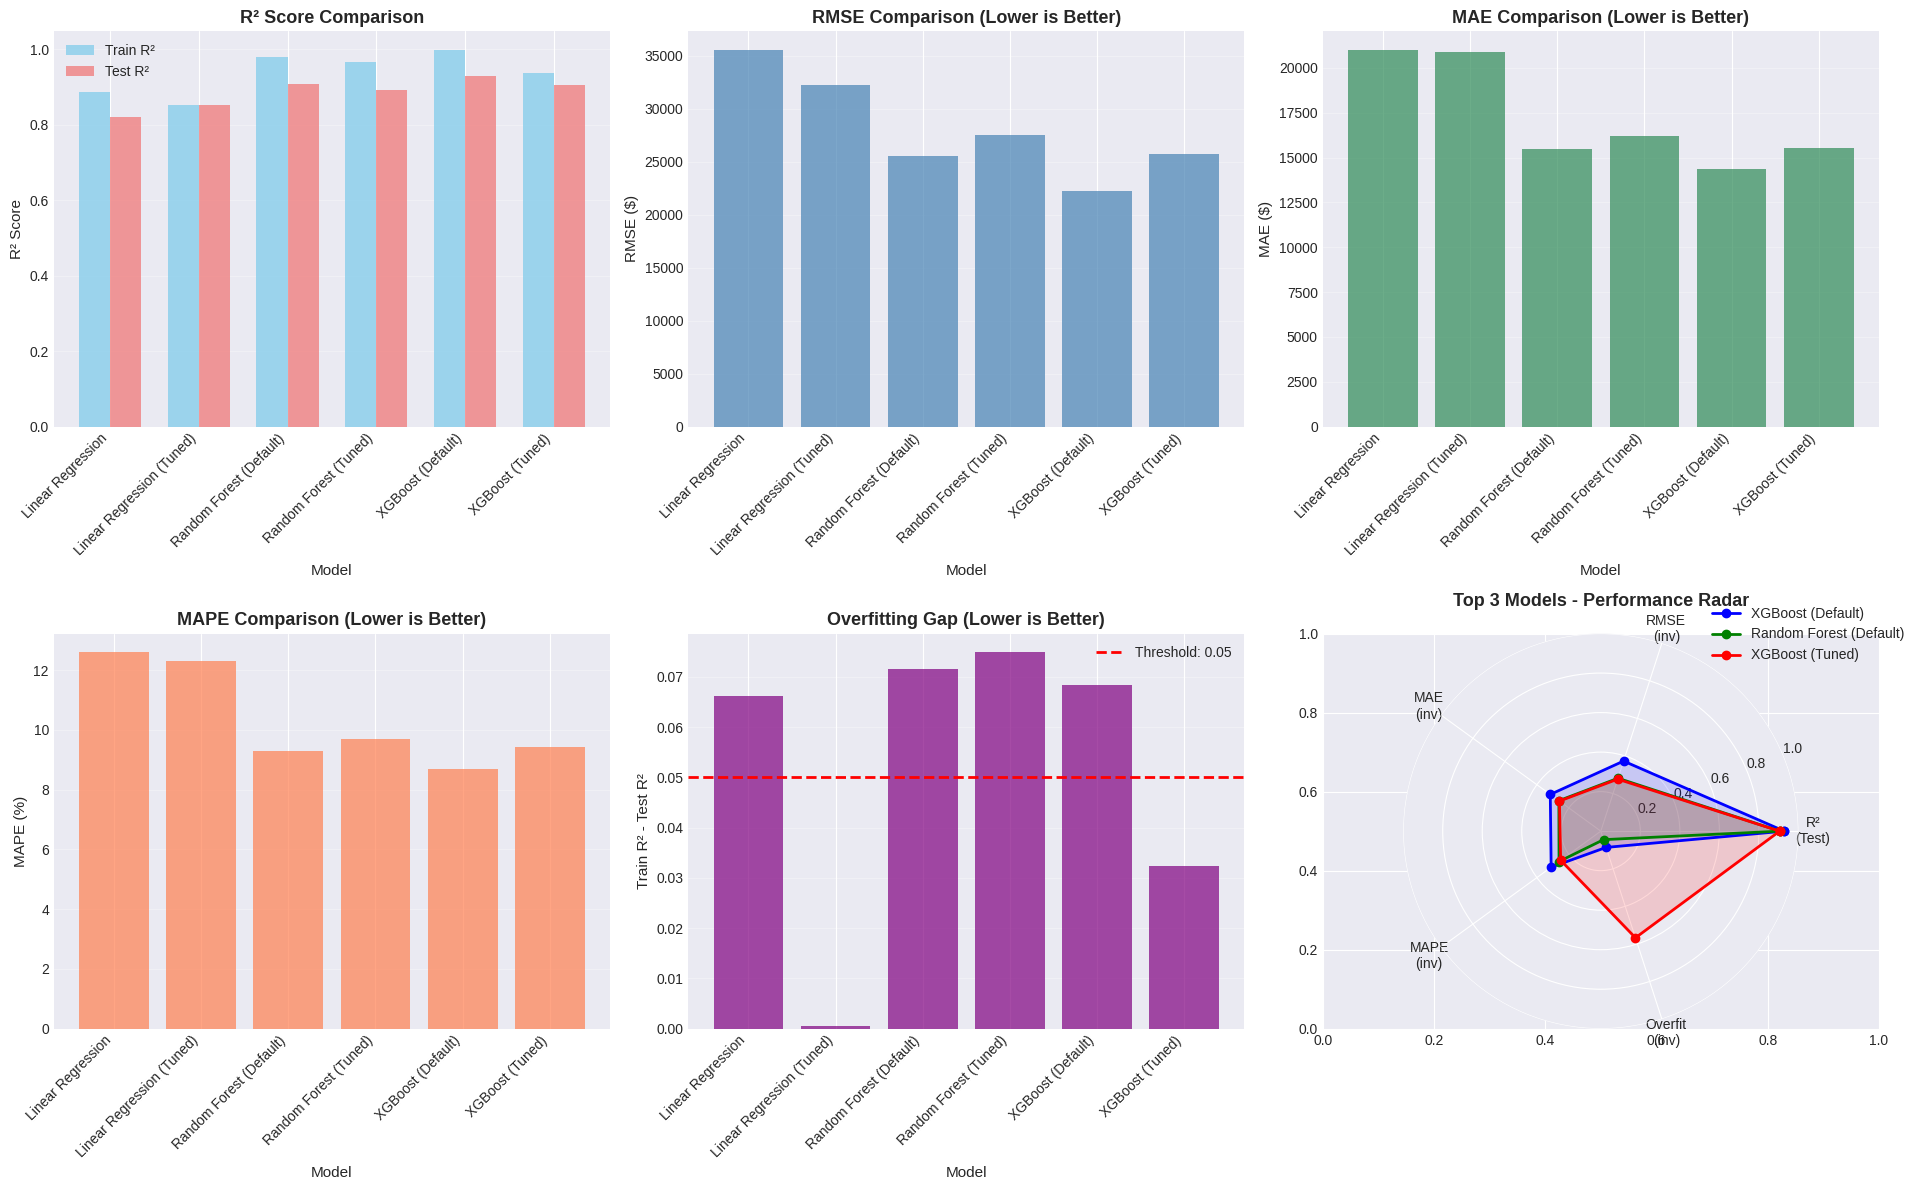

In [54]:
# Visualisasi Perbandingan Model
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. R² Score Comparison
x_pos = np.arange(len(comparison_df))
width = 0.35

axes[0, 0].bar(x_pos - width/2, comparison_df['Train_R2'], width,
               label='Train R²', alpha=0.8, color='skyblue')
axes[0, 0].bar(x_pos + width/2, comparison_df['Test_R2'], width,
               label='Test R²', alpha=0.8, color='lightcoral')
axes[0, 0].set_xlabel('Model', fontsize=11)
axes[0, 0].set_ylabel('R² Score', fontsize=11)
axes[0, 0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')

# 2. RMSE Comparison
axes[0, 1].bar(comparison_df['Model'], comparison_df['Test_RMSE'],
               color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('Model', fontsize=11)
axes[0, 1].set_ylabel('RMSE ($)', fontsize=11)
axes[0, 1].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[0, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0, 1].grid(alpha=0.3, axis='y')

# 3. MAE Comparison
axes[0, 2].bar(comparison_df['Model'], comparison_df['Test_MAE'],
               color='seagreen', alpha=0.7)
axes[0, 2].set_xlabel('Model', fontsize=11)
axes[0, 2].set_ylabel('MAE ($)', fontsize=11)
axes[0, 2].set_title('MAE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[0, 2].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0, 2].grid(alpha=0.3, axis='y')

# 4. MAPE Comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['Test_MAPE'],
               color='coral', alpha=0.7)
axes[1, 0].set_xlabel('Model', fontsize=11)
axes[1, 0].set_ylabel('MAPE (%)', fontsize=11)
axes[1, 0].set_title('MAPE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1, 0].grid(alpha=0.3, axis='y')

# 5. Overfitting Analysis
axes[1, 1].bar(comparison_df['Model'], comparison_df['Overfit_Gap'],
               color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Model', fontsize=11)
axes[1, 1].set_ylabel('Train R² - Test R²', fontsize=11)
axes[1, 1].set_title('Overfitting Gap (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1, 1].axhline(y=0.05, color='r', linestyle='--', linewidth=2, label='Threshold: 0.05')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

# 6. Summary Radar Chart (for best 3 models)
from math import pi

# Normalize metrics for radar chart (0-1 scale)
categories = ['R²\n(Test)', 'RMSE\n(inv)', 'MAE\n(inv)', 'MAPE\n(inv)', 'Overfit\n(inv)']
N = len(categories)

# Select top 3 models by Test R²
top_3_models = comparison_df.nlargest(3, 'Test_R2')

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(2, 3, 6, projection='polar')

colors = ['blue', 'green', 'red']
for idx, (_, row) in enumerate(top_3_models.iterrows()):
    values = [
        row['Test_R2'],
        1 - (row['Test_RMSE'] / comparison_df['Test_RMSE'].max()),  # inverted
        1 - (row['Test_MAE'] / comparison_df['Test_MAE'].max()),    # inverted
        1 - (row['Test_MAPE'] / comparison_df['Test_MAPE'].max()),  # inverted
        1 - (row['Overfit_Gap'] / comparison_df['Overfit_Gap'].max()) # inverted
    ]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_title('Top 3 Models - Performance Radar', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()


🔍 DETAILED ERROR ANALYSIS - BEST MODEL

Error Statistics:
  Mean Error: $-404.21
  Median Error: $-280.16
  Std Error: $22,315.79

  Mean Absolute Error: $14,356.62
  Median Absolute Error: $8,601.00

  Mean Absolute Percentage Error: 8.68%
  Median Absolute Percentage Error: 5.53%

 Prediction Accuracy:
  Within 5% error:  46.12% of predictions
  Within 10% error: 74.43% of predictions
  Within 15% error: 87.44% of predictions
  Within 20% error: 93.15% of predictions


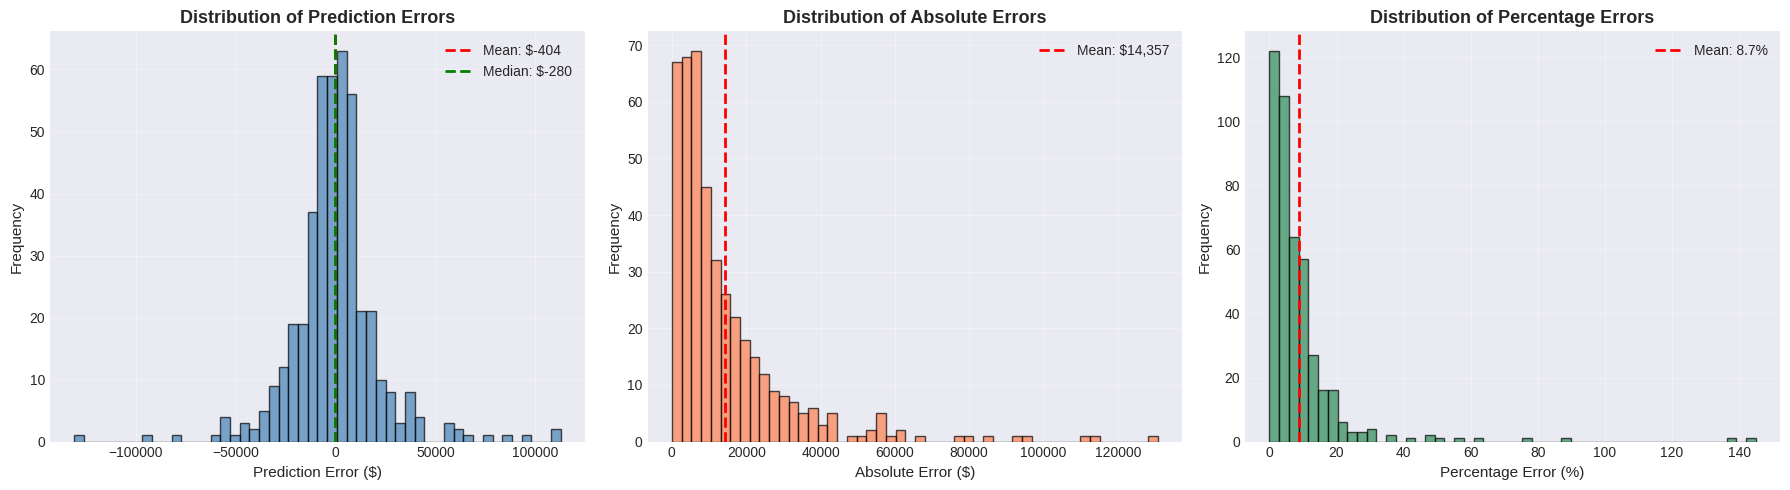

In [55]:
# Prediction Error Analysis untuk Best Model
print("\n" + "="*80)
print("🔍 DETAILED ERROR ANALYSIS - BEST MODEL")
print("="*80)

# Get predictions from best model
if 'XGBoost (Tuned)' in best_model_name:
    best_predictions = y_test_pred_xgb_tuned
elif 'XGBoost (Default)' in best_model_name:
    best_predictions = y_test_pred_xgb
elif 'Random Forest (Tuned)' in best_model_name:
    best_predictions = y_test_pred_rf_tuned
elif 'Random Forest (Default)' in best_model_name:
    best_predictions = y_test_pred_rf
else:
    best_predictions = y_test_pred_lr

# Calculate errors
errors = y_test - best_predictions
abs_errors = np.abs(errors)
pct_errors = (abs_errors / y_test) * 100

# Error statistics
print(f"\nError Statistics:")
print(f"  Mean Error: ${errors.mean():,.2f}")
print(f"  Median Error: ${np.median(errors):,.2f}")
print(f"  Std Error: ${errors.std():,.2f}")
print(f"\n  Mean Absolute Error: ${abs_errors.mean():,.2f}")
print(f"  Median Absolute Error: ${np.median(abs_errors):,.2f}")
print(f"\n  Mean Absolute Percentage Error: {pct_errors.mean():.2f}%")
print(f"  Median Absolute Percentage Error: {np.median(pct_errors):.2f}%")

# Percentage of predictions within certain error ranges
within_5pct = (pct_errors <= 5).sum() / len(pct_errors) * 100
within_10pct = (pct_errors <= 10).sum() / len(pct_errors) * 100
within_15pct = (pct_errors <= 15).sum() / len(pct_errors) * 100
within_20pct = (pct_errors <= 20).sum() / len(pct_errors) * 100

print(f"\n Prediction Accuracy:")
print(f"  Within 5% error:  {within_5pct:.2f}% of predictions")
print(f"  Within 10% error: {within_10pct:.2f}% of predictions")
print(f"  Within 15% error: {within_15pct:.2f}% of predictions")
print(f"  Within 20% error: {within_20pct:.2f}% of predictions")

# Visualize error distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Error Distribution
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${errors.mean():,.0f}')
axes[0].axvline(np.median(errors), color='green', linestyle='--', linewidth=2, label=f'Median: ${np.median(errors):,.0f}')
axes[0].set_xlabel('Prediction Error ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Prediction Errors', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Absolute Error Distribution
axes[1].hist(abs_errors, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(abs_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${abs_errors.mean():,.0f}')
axes[1].set_xlabel('Absolute Error ($)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Absolute Errors', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Percentage Error Distribution
axes[2].hist(pct_errors, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].axvline(pct_errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {pct_errors.mean():.1f}%')
axes[2].set_xlabel('Percentage Error (%)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Distribution of Percentage Errors', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Kesimpulan

###  Kesimpulan

In [57]:
print("="*80)
print(" KESIMPULAN")
print("="*80)

# Tentukan model terbaik dari comparison_df berdasarkan Test_R2
best_model_idx = comparison_df['Test_R2'].idxmax()

# Sinkronkan variabel (biar konsisten)
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_r2 = comparison_df.loc[best_model_idx, 'Test_R2']
best_rmse = comparison_df.loc[best_model_idx, 'Test_RMSE']

print("\n KESIMPULAN UTAMA:")
print("="*80)

print(f"\n1. MODEL TERBAIK: {best_model_name}")
print(f"   - Test R² Score: {best_r2:.6f}")
print(f"   - Test RMSE: ${best_rmse:,.2f}")
print(f"   - Model ini mampu menjelaskan {best_r2*100:.2f}% variance dalam harga rumah")

print(f"\n2. PERBANDINGAN PERFORMA:")
print(f"   - Linear Regression (Baseline): R² = {lr_test_metrics['R2']:.6f}")
print(f"   - Random Forest (Default): R² = {rf_test_metrics['R2']:.6f}")
print(f"   - Random Forest (Tuned): R² = {rf_tuned_test_metrics['R2']:.6f}")
print(f"    - XGBoost (Default): R² = {xgb_test_metrics['R2']:.6f}")
print(f"   - XGBoost (Tuned): R² = {xgb_tuned_test_metrics['R2']:.6f}")

improvement_over_baseline = ((best_r2 - lr_test_metrics['R2']) / lr_test_metrics['R2']) * 100
print(f"\n3. IMPROVEMENT:")
print(f"   - Model terbaik meningkat {improvement_over_baseline:.2f}% dibanding baseline")
print(f"   - RMSE berkurang ${lr_test_metrics['RMSE'] - best_rmse:,.2f}")

print(f"\n4. FEATURE IMPORTANCE:")
print(f"   Top 3 features paling berpengaruh terhadap harga:")
if 'XGBoost' in best_model_name:
    top_features = feature_importance_xgb.head(3)
elif 'Random Forest' in best_model_name:
    top_features = feature_importance_rf.head(3)
else:
    top_features = feature_importance.head(3)

for idx, row in top_features.iterrows():
    if 'Importance' in row:
        print(f"   - {row['Feature']}: {row['Importance']:.4f}")
    else:
        print(f"   - {row['Feature']}: {abs(row['Coefficient']):.4f}")

print(f"\n5 MODEL GENERALIZATION:")
overfit_gap = comparison_df.loc[best_model_idx, 'Overfit_Gap']
if overfit_gap < 0.05:
    print(f"    Model generalisasi dengan baik (gap: {overfit_gap:.4f})")
elif overfit_gap < 0.1:
    print(f"    Model sedikit overfit (gap: {overfit_gap:.4f})")
else:
    print(f"    Model cenderung overfit (gap: {overfit_gap:.4f})")

print("\n" + "="*80)
print("ANALISIS SELESAI!")
print("="*80)

 KESIMPULAN DAN REKOMENDASI

 KESIMPULAN UTAMA:

1. MODEL TERBAIK: XGBoost (Default)
   - Test R² Score: 0.928774
   - Test RMSE: $22,293.96
   - Model ini mampu menjelaskan 92.88% variance dalam harga rumah

2. PERBANDINGAN PERFORMA:
   - Linear Regression (Baseline): R² = 0.818874
   - Random Forest (Default): R² = 0.906504
   - Random Forest (Tuned): R² = 0.891662
    - XGBoost (Default): R² = 0.928774
   - XGBoost (Tuned): R² = 0.905258

3. IMPROVEMENT:
   - Model terbaik meningkat 13.42% dibanding baseline
   - RMSE berkurang $13,257.58

4. FEATURE IMPORTANCE:
   Top 3 features paling berpengaruh terhadap harga:
   - OverallQual: 0.3448
   - TotalSF: 0.1378
   - BsmtQual: 0.0491

5 MODEL GENERALIZATION:
    Model sedikit overfit (gap: 0.0684)

ANALISIS SELESAI!


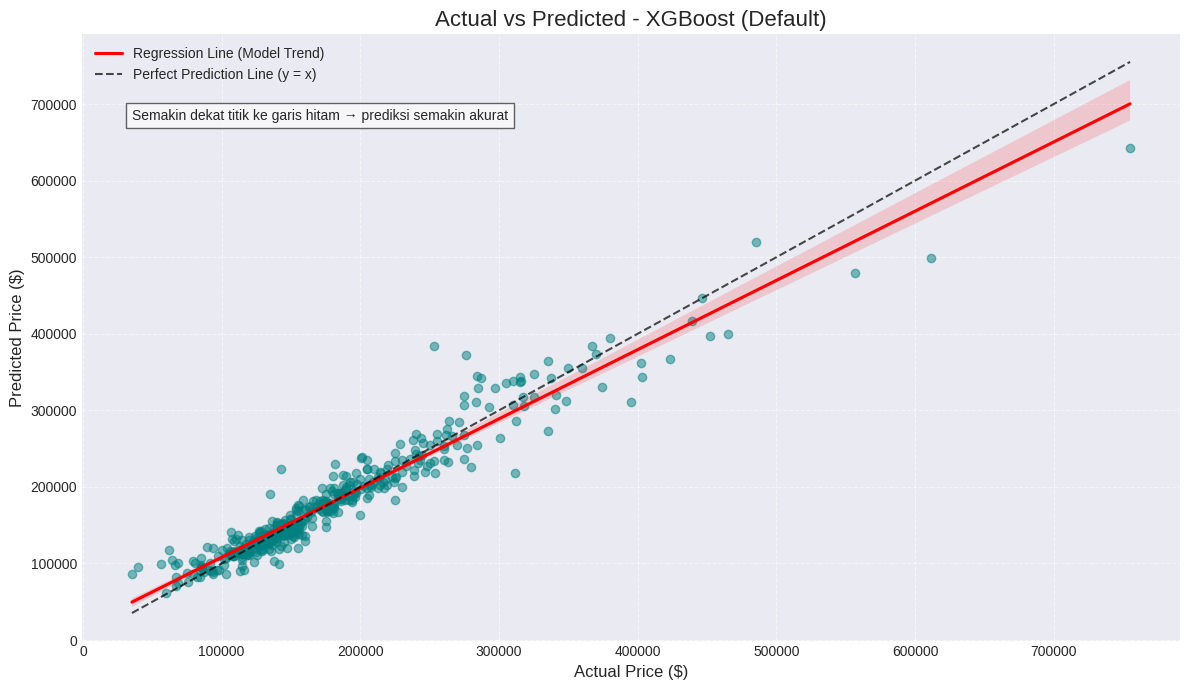

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pilih prediksi berdasarkan best_model_name
if "XGBoost (Default)" in best_model_name:
    y_final_pred = y_test_pred_xgb
elif "XGBoost (Tuned)" in best_model_name:
    y_final_pred = y_test_pred_xgb_tuned
elif "Random Forest" in best_model_name:
    y_final_pred = y_test_pred_rf_tuned if "Tuned" in best_model_name else y_test_pred_rf
else:
    y_final_pred = y_test_pred_lr


# =========================
# ACTUAL VS PREDICTED
# =========================
plt.figure(figsize=(12, 7))

# Scatter + regression line
sns.regplot(
    x=y_test,
    y=y_final_pred,
    scatter_kws={
        'alpha': 0.5,
        'color': 'teal',
        'label': 'Data Points (Actual vs Predicted)'
    },
    line_kws={
        'color': 'red',
        'label': 'Regression Line (Model Trend)'
    }
)

# Garis ideal (y = x)
max_val = max(max(y_test), max(y_final_pred))
min_val = min(min(y_test), min(y_final_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='black',
    linestyle='--',
    alpha=0.7,
    label='Perfect Prediction Line (y = x)'
)

plt.text(
    min_val,
    max_val * 0.9,
    "Semakin dekat titik ke garis hitam → prediksi semakin akurat",
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.title(f'Actual vs Predicted - {best_model_name}', fontsize=16)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()
plt.tight_layout()



plt.show()